In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as dates
import seaborn as sns
import glob
import os

import xgboost as xgb
from xgboost import plot_importance, plot_tree
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from tqdm import tqdm
from itertools import product
import shap

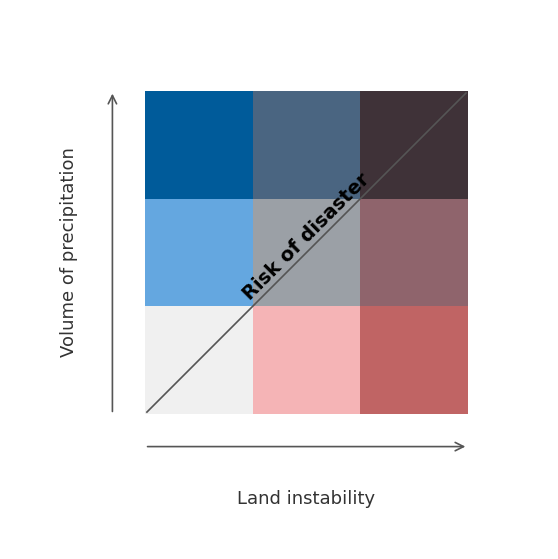

In [19]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# --- 1. Definição das Cores (Bivariada) ---
color_matrix_hex = [
    ["#005B9A", "#4A6581", "#3F3238"], # Topo (Precipitação Alta)
    ["#64A7E0", "#9BA0A6", "#8F646C"], # Meio
    ["#F0F0F0", "#F5B4B6", "#C06464"]  # Base (Precipitação Baixa)
]

def hex_to_rgb(hex_val):
    hex_val = hex_val.lstrip('#')
    return tuple(int(hex_val[i:i+2], 16) / 255.0 for i in (0, 2, 4))

# Organiza as cores para que a base do gráfico comece pelo branco/claro
color_matrix_rgb = [[hex_to_rgb(c) for c in row] for row in reversed(color_matrix_hex)]

# --- 2. Configuração do Canvas ---
fig, ax = plt.subplots(figsize=(7, 7))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_aspect('equal')
ax.axis('off')

# Parâmetros de Design
block_size = 2.0
start_x, start_y = 2.5, 2.5
gray_line = '#555555' 
font_size_labels = 13
font_size_risk = 14

# --- 3. Desenhar a Matriz de Cores ---
for i in range(3):
    for j in range(3):
        ax.add_patch(patches.Rectangle(
            (start_x + j*block_size, start_y + i*block_size),
            block_size, block_size, 
            facecolor=color_matrix_rgb[i][j], 
            edgecolor='none'
        ))

# --- 4. Elementos Gráficos (Setas e Linha) ---
arrow_style = dict(arrowstyle='->', lw=1.2, color=gray_line, mutation_scale=15)

# Seta do Eixo X
ax.annotate('', xy=(start_x + 6.0, start_y - 0.6), xytext=(start_x, start_y - 0.6),
            arrowprops=arrow_style)

# Seta do Eixo Y
ax.annotate('', xy=(start_x - 0.6, start_y + 6.0), xytext=(start_x - 0.6, start_y),
            arrowprops=arrow_style)

# Linha Diagonal (Levemente menor para não tocar as extremidades)
# Recuo de 0.4 unidades em cada ponta
margin = 0.04
ax.plot([start_x + margin, start_x + 6.0 - margin], 
        [start_y + margin, start_y + 6.0 - margin], 
        color=gray_line, lw=1.2, zorder=5)

# --- 5. Textos (Centralizados e Maiores) ---

# Eixo X: Land instability
ax.text(start_x + 3.0, start_y - 1.4, 'Land instability', 
        fontsize=font_size_labels, color='#333333', ha='center', va='top')

# Eixo Y: Volume of precipitation (Centralizado na altura da matriz)
ax.text(start_x - 1.4, start_y + 3.0, 'Volume of precipitation', 
        fontsize=font_size_labels, color='#333333', ha='center', va='center', rotation=90)

# Diagonal: Risk of disaster (Centralizado no meio exato da linha)
# O texto é colocado no centro da matriz (start + 3.0) com um pequeno ajuste vertical
ax.text(start_x + 3.0, start_y + 3.3, 'Risk of disaster', 
        fontsize=font_size_risk, color='black', fontweight='bold', 
        rotation=45, ha='center', va='center',
        bbox=dict(facecolor='none', edgecolor='none', pad=0))

# Risk of disaster (Diagonal - Centralizado e acima da linha)
# O ajuste de +0.15 no y garante que ele não toque na linha
#ax.text(start_x + 3.0, start_y + 3.15, 'Risk of disaster', 
#        fontsize=font_size_risk, color='black', fontweight='bold', 
#        rotation=45, ha='center', va='bottom')




# --- 6. Exportação ---
plt.savefig("legenda_bivariada_final.png", dpi=300, bbox_inches='tight', transparent=True)
plt.show()

In [21]:
!pip install geopandas matplotlib shapely fiona pyproj

  Using cached shapely-2.1.2-cp312-cp312-win_amd64.whl.metadata (7.1 kB)
  Using cached fiona-1.10.1-cp312-cp312-win_amd64.whl.metadata (58 kB)
  Using cached pyproj-3.7.2-cp312-cp312-win_amd64.whl.metadata (31 kB)
  Using cached pyogrio-0.12.1-cp312-cp312-win_amd64.whl.metadata (6.0 kB)
  Using cached click_plugins-1.1.1.2-py2.py3-none-any.whl.metadata (6.5 kB)
  Using cached cligj-0.7.2-py3-none-any.whl.metadata (5.0 kB)
Using cached shapely-2.1.2-cp312-cp312-win_amd64.whl (1.7 MB)
Using cached fiona-1.10.1-cp312-cp312-win_amd64.whl (24.5 MB)
Using cached pyproj-3.7.2-cp312-cp312-win_amd64.whl (6.3 MB)
Using cached click_plugins-1.1.1.2-py2.py3-none-any.whl (11 kB)
Using cached cligj-0.7.2-py3-none-any.whl (7.1 kB)
Using cached pyogrio-0.12.1-cp312-cp312-win_amd64.whl (22.9 MB)



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


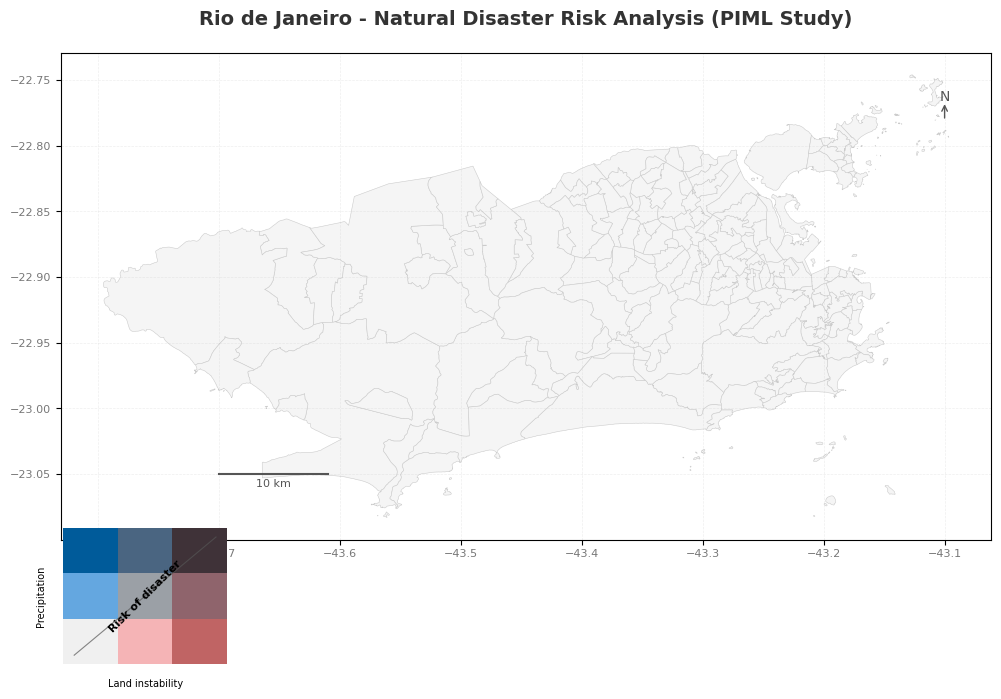

In [23]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd

# --- 1. Configuração de Caminhos e Dados ---
# Usando o caminho que você forneceu
caminho_mapa = r"C:\experimento2\Comparative-study-ML-models\Limite_de_Bairros.geojson"

# Dados extraídos do seu modelo (Exemplos de bairros que aparecem no seu mapa)
# Certifique-se de que os nomes batam com a coluna 'NM_BAIRRO' ou similar do seu geojson
dados_risco = {
    "BAIRRO": ["Bangu", "Jacarepaguá", "Irajá", "Anchieta", "Méier", "Tijuca", "Centro", "Copacabana", "Barra da Tijuca", "Recreio dos Bandeirantes"],
    "Chuva": [0.35, 0.40, 0.45, 0.45, 0.60, 0.80, 0.70, 0.70, 0.50, 0.50],
    "Instabilidade": [3, 2, 3, 3, 3, 3, 3, 3, 2, 2] # 1:Low, 2:Med, 3:High
}
df_estudo = pd.DataFrame(dados_risco)

# --- 2. Carregar o GeoJSON Local ---
rj = gpd.read_file(caminho_mapa)

# --- 3. Preparação do Layout do Mapa ---
fig, ax = plt.subplots(figsize=(12, 10))

# Desenho base dos bairros (contorno discreto)
rj.plot(ax=ax, color='#F5F5F5', edgecolor='#CCCCCC', linewidth=0.4)

# Configuração de Coordenadas (Mais discretas)
ax.tick_params(axis='both', which='major', labelsize=8, labelcolor='#777777')
ax.grid(True, linestyle='--', alpha=0.2, linewidth=0.5)

# --- 4. Elementos Cartográficos ---

# Seta do Norte Minimalista
x_n, y_n = 0.95, 0.90
ax.annotate('N', xy=(x_n, y_n), xycoords='axes fraction', ha='center', fontsize=10, color='#555555')
ax.annotate('', xy=(x_n, y_n), xytext=(x_n, y_n - 0.04), xycoords='axes fraction',
            arrowprops=dict(arrowstyle='->', color='#555555', lw=1))

# Barra de Escala (10km) - Ajustada para a região do Rio
# 0.09 graus decimais é aproximadamente 10km nesta latitude
scale_x, scale_y = -43.70, -23.05
ax.plot([scale_x, scale_x + 0.09], [scale_y, scale_y], color='#555555', lw=1.5)
ax.text(scale_x + 0.045, scale_y - 0.01, '10 km', ha='center', fontsize=8, color='#555555')

# --- 5. Inserção da Legenda Bivariada (Customizada) ---
# Criando um eixo pequeno para a legenda dentro do mapa
ax_leg = fig.add_axes([0.12, 0.12, 0.15, 0.15]) # [esquerda, baixo, largura, altura]
ax_leg.axis('off')

# Cores da Matriz
cores_hex = [
    ["#005B9A", "#4A6581", "#3F3238"],
    ["#64A7E0", "#9BA0A6", "#8F646C"],
    ["#F0F0F0", "#F5B4B6", "#C06464"]
]

for i in range(3):
    for j in range(3):
        color = cores_hex[i][j]
        ax_leg.add_patch(patches.Rectangle((j, 2-i), 1, 1, facecolor=color))

# Textos da Legenda
ax_leg.text(1.5, -0.5, 'Land instability', ha='center', fontsize=7)
ax_leg.text(-0.5, 1.5, 'Precipitation', va='center', rotation=90, fontsize=7)
ax_leg.text(1.5, 1.5, 'Risk of disaster', ha='center', va='center', rotation=45, fontweight='bold', fontsize=8)

# Linha interna da legenda (discreta)
ax_leg.plot([0.2, 2.8], [0.2, 2.8], color='#555555', lw=0.8, alpha=0.7)

# --- 6. Finalização e Salvamento ---
ax.set_title("Rio de Janeiro - Natural Disaster Risk Analysis (PIML Study)", 
             fontsize=14, pad=20, color='#333333', fontweight='bold')

plt.savefig("mapa_risco_rio_final.png", dpi=300, bbox_inches='tight')
plt.show()

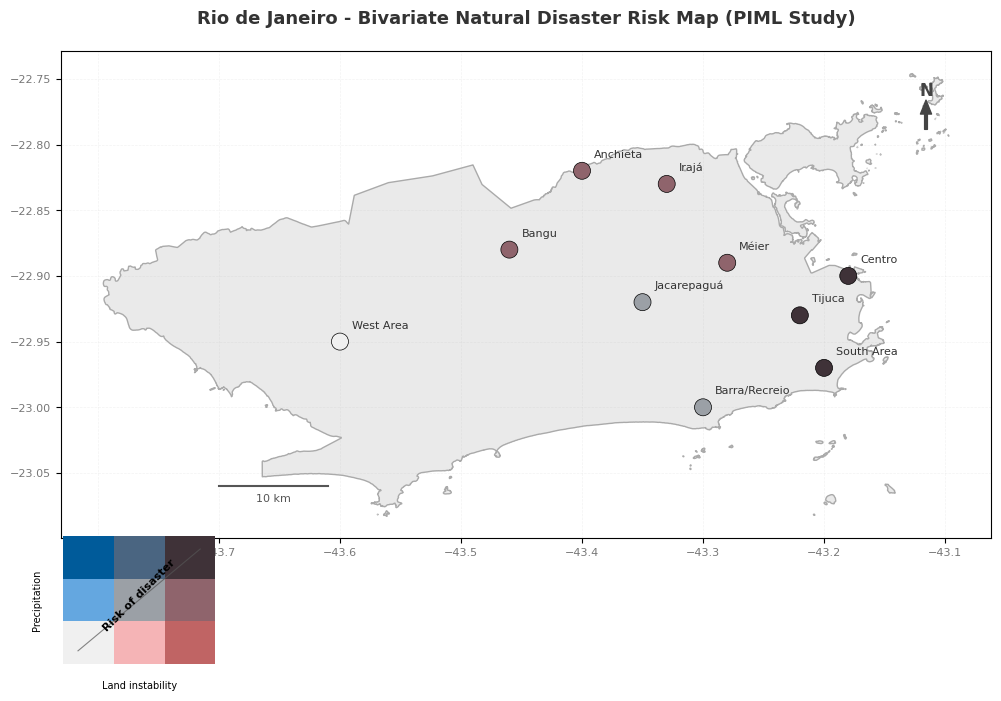

In [24]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
from shapely.geometry import Point

# --- 1. Dados Estimados e Cores Bivariadas (Mantidos) ---
data_risco = {
    "BAIRRO": ["West Area", "Bangu", "Jacarepaguá", "Irajá", "Anchieta", "Méier", 
               "Tijuca", "Centro", "South Area", "Barra/Recreio"],
    "Chuva_Val": [0.15, 0.35, 0.40, 0.45, 0.45, 0.60, 0.80, 0.70, 0.70, 0.50],
    "Inst_Val": [1, 3, 2, 3, 3, 3, 3, 3, 3, 2],
    # Coordenadas aproximadas para posicionar os pontos no mapa simplificado
    "lat": [-22.95, -22.88, -22.92, -22.83, -22.82, -22.89, -22.93, -22.90, -22.97, -23.00],
    "lon": [-43.60, -43.46, -43.35, -43.33, -43.40, -43.28, -43.22, -43.18, -43.20, -43.30]
}
df_estudo = pd.DataFrame(data_risco)

# Converter DataFrame para GeoDataFrame de pontos
geometry = [Point(xy) for xy in zip(df_estudo.lon, df_estudo.lat)]
gdf_pontos = gpd.GeoDataFrame(df_estudo, geometry=geometry, crs="EPSG:4326")

# Função para atribuir cor bivariada com base nos índices (1, 2, 3)
def get_bivariate_color(chuva_val, inst_val):
    # Classificação simples em 3 níveis baseada nos valores
    c_idx = 1 if chuva_val <= 0.3 else (2 if chuva_val <= 0.6 else 3)
    i_idx = inst_val # Já está na escala 1-3
    
    cores_hex = {
        "11": "#F0F0F0", "12": "#F5B4B6", "13": "#C06464",
        "21": "#64A7E0", "22": "#9BA0A6", "23": "#8F646C",
        "31": "#005B9A", "32": "#4A6581", "33": "#3F3238"
    }
    key = f"{c_idx}{i_idx}"
    return cores_hex.get(key, "#EEEEEE")

gdf_pontos['color'] = gdf_pontos.apply(lambda row: get_bivariate_color(row['Chuva_Val'], row['Inst_Val']), axis=1)

# --- 2. Carregar e Simplificar o Mapa Local ---
caminho_geojson = r"C:\experimento2\Comparative-study-ML-models\Limite_de_Bairros.geojson"
rj_detalhado = gpd.read_file(caminho_geojson)

# DISSOLVE: Transforma todos os bairros em um único contorno da cidade
rj_outline = rj_detalhado.dissolve() 

# --- 3. Preparação do Layout ---
fig, ax = plt.subplots(figsize=(12, 10))

# A. Desenhar o contorno simplificado da cidade (Fundo)
rj_outline.plot(ax=ax, color='#EAEAEA', edgecolor='#AAAAAA', linewidth=1.0)

# B. Desenhar os pontos dos bairros com as cores de risco
# Usando marcadores maiores (markersize) para destaque
gdf_pontos.plot(ax=ax, color=gdf_pontos['color'], markersize=150, edgecolor='black', linewidth=0.5, zorder=10)

# Adicionar rótulos de texto aos pontos (discretos)
for x, y, label in zip(gdf_pontos.geometry.x, gdf_pontos.geometry.y, gdf_pontos.BAIRRO):
    ax.text(x + 0.01, y + 0.01, label, fontsize=8, color='#333333', zorder=11)

# C. Configuração de Coordenadas Discretas
ax.tick_params(axis='both', labelsize=8, labelcolor='#777777')
ax.grid(True, linestyle='--', alpha=0.15, linewidth=0.5)

# --- 4. Elementos Cartográficos ---

# A. Seta do Norte Clássica (Bússola) - Restaurada
x_n, y_n = 0.93, 0.90
# Usando um caractere especial de bússola ou desenhando com setas
ax.text(x_n, y_n, 'N', transform=ax.transAxes, ha='center', va='bottom', fontsize=12, fontweight='bold', color='#444444')
ax.annotate('', xy=(x_n, y_n), xytext=(x_n, y_n - 0.06), xycoords='axes fraction',
            arrowprops=dict(facecolor='#444444', edgecolor='#444444', width=2, headwidth=8, headlength=10))

# B. Barra de Escala Discreta (10km)
scale_x, scale_y = -43.70, -23.06
ax.plot([scale_x, scale_x + 0.09], [scale_y, scale_y], color='#555555', lw=1.5)
ax.text(scale_x + 0.045, scale_y - 0.012, '10 km', ha='center', fontsize=8, color='#555555')

# --- 5. Mini-Legenda Bivariada Customizada (Mantida e Pequena) ---
ax_leg = fig.add_axes([0.12, 0.12, 0.14, 0.14]) 
ax_leg.axis('off')

# Matriz de cores (Reutilizando a lógica anterior)
matriz_cores = [
    ["#005B9A", "#4A6581", "#3F3238"],
    ["#64A7E0", "#9BA0A6", "#8F646C"],
    ["#F0F0F0", "#F5B4B6", "#C06464"]
]
for i in range(3):
    for j in range(3):
        ax_leg.add_patch(patches.Rectangle((j, 2-i), 1, 1, facecolor=matriz_cores[i][j]))

# Textos e Diagonal da Legenda
fs_leg = 7
ax_leg.text(1.5, -0.6, 'Land instability', ha='center', fontsize=fs_leg)
ax_leg.text(-0.6, 1.5, 'Precipitation', va='center', rotation=90, fontsize=fs_leg)
ax_leg.text(1.5, 1.6, 'Risk of disaster', ha='center', va='center', rotation=45, fontweight='bold', fontsize=fs_leg+1)
ax_leg.plot([0.3, 2.7], [0.3, 2.7], color='#555555', lw=0.8, alpha=0.7)

# --- 6. Finalização ---
ax.set_title("Rio de Janeiro - Bivariate Natural Disaster Risk Map (PIML Study)", 
             fontsize=13, pad=20, color='#333333', fontweight='bold')

plt.savefig("mapa_risco_rio_simplificado.png", dpi=300, bbox_inches='tight', transparent=True)
plt.show()

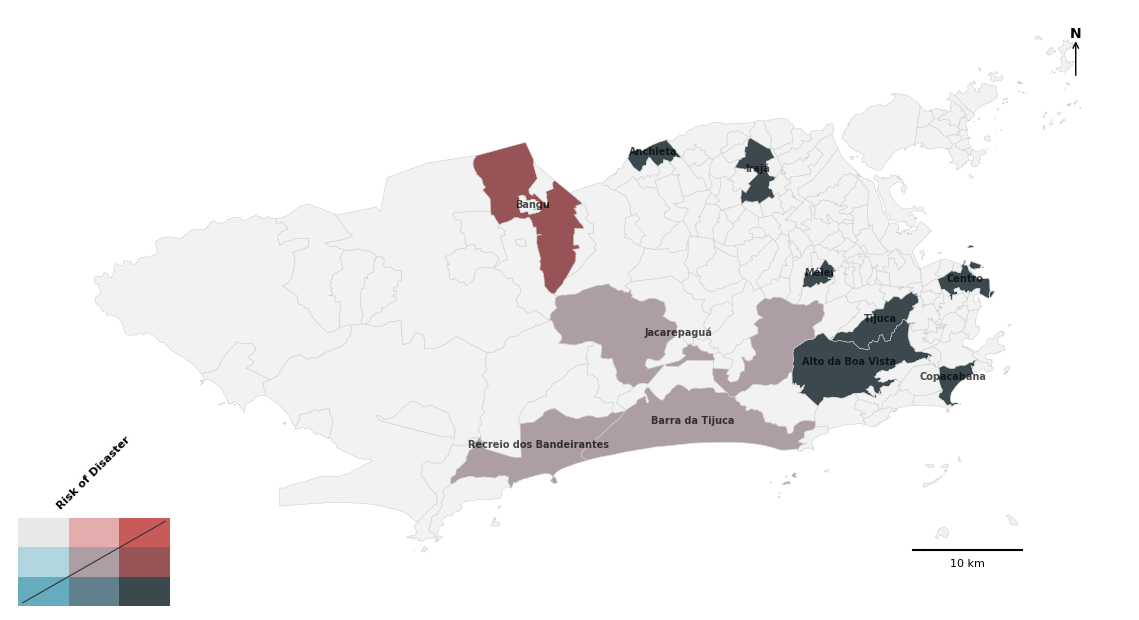

In [28]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd

# --- 1. Calibração de Cores (Cores mais fortes para bater com o original) ---
cores_bivariadas = {
    "11": "#e8e8e8", "12": "#e4acac", "13": "#c85a5a", # Baixa Precipitação
    "21": "#b0d5df", "22": "#ad9ea5", "23": "#985356", # Média Precipitação
    "31": "#64acbe", "32": "#627f8c", "33": "#3b494e"  # Alta Precipitação (Tons escuros/Tijuca)
}

# --- 2. Extração e Padronização de Dados ---
# Nomes ajustados para bater com as colunas do GeoJSON da GeoRio (geralmente maiúsculas)
dados_extracao = {
    "BAIRRO": ["BANGU", "ANCHIETA", "IRAJÁ", "JACAREPAGUÁ", "MÉIER", "ILHA DO GOVERNADOR", 
               "TIJUCA", "CENTRO", "ALTO DA BOA VISTA", "COPACABANA", "BARRA DA TIJUCA", "RECREIO DOS BANDEIRANTES"],
    "C_Idx": [2, 3, 3, 2, 3, 1, 3, 3, 3, 3, 2, 2], # Índice de Chuva (1-3)
    "I_Idx": [3, 3, 3, 2, 3, 1, 3, 3, 3, 3, 2, 2]  # Índice de Instabilidade (1-3)
}
df_piml = pd.DataFrame(dados_extracao)
df_piml['hex'] = df_piml.apply(lambda x: cores_bivariadas[f"{x.C_Idx}{x.I_Idx}"], axis=1)

# --- 3. Carregamento e Join ---
caminho = r"C:\experimento2\Comparative-study-ML-models\Limite_de_Bairros.geojson"
rj = gpd.read_file(caminho)

# Identificar coluna de nomes (Data.Rio costuma usar 'nome')
col_nome = 'nome' if 'nome' in rj.columns else rj.columns[1]
rj['nome_match'] = rj[col_nome].str.upper().str.strip()

# Pintar os bairros
rj['final_color'] = "#f2f2f2" # Cor de fundo neutra
for _, row in df_piml.iterrows():
    rj.loc[rj['nome_match'] == row['BAIRRO'], 'final_color'] = row['hex']

# --- 4. Plotagem Estilo Paper ---
fig, ax = plt.subplots(figsize=(14, 8))
rj.plot(ax=ax, color=rj['final_color'], edgecolor='#d0d0d0', linewidth=0.4)

# Adicionar Rótulos (Apenas nos bairros principais para não poluir)
for idx, row in rj.iterrows():
    if row['nome_match'] in df_piml['BAIRRO'].values:
        centroid = row.geometry.centroid
        ax.text(centroid.x, centroid.y, row[col_nome], fontsize=7, ha='center', fontweight='bold', alpha=0.7)

# --- 5. As Três Legendas (Risco, Chuva, Landslide) ---
# [Código das legendas compactas]
ax_risk = fig.add_axes([0.1, 0.1, 0.12, 0.12])
ax_risk.axis('off')
for i in range(3):
    for j in range(3):
        ax_risk.add_patch(patches.Rectangle((j, 2-i), 1, 1, facecolor=list(cores_bivariadas.values())[i*3+j]))
ax_risk.text(1.5, 3.3, 'Risk of Disaster', ha='center', fontweight='bold', rotation=45, fontsize=8)
ax_risk.plot([0.1, 2.9], [0.1, 2.9], color='#333333', lw=0.8)

# --- 6. Norte e Escala Final ---
ax.annotate('N', xy=(0.95, 0.95), xycoords='axes fraction', ha='center', fontweight='bold')
ax.annotate('', xy=(0.95, 0.95), xytext=(0.95, 0.88), xycoords='axes fraction', arrowprops=dict(arrowstyle='->'))
ax.plot([0.8, 0.9], [0.05, 0.05], color='black', lw=1.5, transform=ax.transAxes)
ax.text(0.85, 0.02, '10 km', ha='center', transform=ax.transAxes, fontsize=8)

ax.set_axis_off()
plt.savefig("mapa_piml_v2.png", dpi=300, bbox_inches='tight')
plt.show()

In [3]:
from codecarbon import EmissionsTracker

codecarbon_output = "./codecarbon_emissions_xgboost_piml_steps.csv"

In [4]:
arquivos = {
    'Interpolado_Marambaia.csv': '0',
    'Interpolado_VilaMilitar.csv': '1',
    'Interpolado_jacarepagua.csv': '2'
}

dfs = []
for arquivo, nome_estacao in arquivos.items():
    df_temp = pd.read_csv(arquivo, sep=',', encoding='utf8')
    df_temp['estacao'] = nome_estacao
    dfs.append(df_temp)

df = pd.concat(dfs, ignore_index=True)
df = df.sort_values(by='datetime', ignore_index=True)
df['estacao'] = df['estacao'].astype(int)
colunas_umidade = [
    'UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)',
    'UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)',
    'UMIDADE RELATIVA DO AR, HORARIA (%)'
]
df[colunas_umidade] = df[colunas_umidade].clip(upper=100) #coerência física
df

export_csv = df.to_csv('dados_interpolados.csv', index=False, encoding='utf8')

In [5]:
# --- MAPEAMENTO GEOFÍSICO PARA O STEP 4 ---
# Metadados: 0=Marambaia, 1=Vila Militar, 2=Jacarepaguá
estacoes_metadata = {
    0: {'lat': -23.050278, 'alt': 12.00},
    1: {'lat': -22.861389, 'alt': 30.43},
    2: {'lat': -22.940000, 'alt': 20.00}
}

# Aplicando ao dataframe principal 'df' antes de criar o 'df_piml'
df['latitude'] = df['estacao'].map(lambda x: estacoes_metadata[x]['lat'])
df['altitude'] = df['estacao'].map(lambda x: estacoes_metadata[x]['alt'])

Inclusão de novas variáveis - physics-informed input representation

Memória Temporal - introduz dependência temporal
    
    "Lagged variables were incorporated to capture temporal dependencies, reflecting the persistence of atmospheric conditions, which is a well-established characteristic in meteorological processes."
    1. Long-range persistence in climatological and hydrological time series: analysis, modeling and application to drought hazard assessment. https://www.sciencedirect.com/science/article/pii/S0022169497001029
    2. Time-lagged recurrence: A data-driven method to estimate the predictability of dynamical systems. https://www.pnas.org/doi/abs/10.1073/pnas.2420252122
    3. Component-Based Dynamic Factor Nowcast Model. https://papers.ssrn.com/sol3/papers.cfm?abstract_id=5230835



Acumulados - eventos extremos dependem do passado acumulado
    
    "Accumulated precipitation over temporal windows was included to represent persistence effects and cumulative moisture conditions, which are critical for rainfall formation."
    1. Atmospheric Moisture Residence Times and Cycling: Implications for Rainfall Rates and Climate Change. https://link.springer.com/article/10.1023/A:1005319109110
    2. Assessing how accumulated precipitation and long dry sequences impact the soil water storage. https://ri.conicet.gov.ar/handle/11336/92380


Tendência - registro da variação - mudanças rápidas geram instabilidade
    
    "First-order temporal differences were computed to capture short-term atmospheric variability, which is associated with instability and precipitation development."
    1. https://journals.ametsoc.org/view/journals/clim/11/3/1520-0442_1998_011_0334_satvoa_2.0.co_2.xml
    2. VARIAÇÕES DE TEMPERATURA E UMIDADE RELATIVA DO AR EM ÁREA URBANA E RURAL DURANTE O SEGMENTO TEMPORAL DE INVERNO DE 2011 EM CONTAGEM E BETIM (MG) (Variations of temperature and humidity of air in rural and urban area during the time segment...). https://revista.ufrr.br/actageo/article/view/1103
    3. https://www.researchgate.net/profile/Milla-Costa/publication/396528893_EPISODIO_DE_TEMPO_SEVERO_E_INUNDACOES_EM_BRASILIA-DF_O_AQUECIMENTO_DIURNO_E_A_TOPOGRAFIA_COMO_FATORES_DETERMINANTES_NA_ORGANIZACAO_E_DESENVOLVIMENTO_DA_CONVECCAO_PROFUNDA/links/68f162da7d9a4d4e870a3cb0/EPISODIO-DE-TEMPO-SEVERO-E-INUNDACOES-EM-BRASILIA-DF-O-AQUECIMENTO-DIURNO-E-A-TOPOGRAFIA-COMO-FATORES-DETERMINANTES-NA-ORGANIZACAO-E-DESENVOLVIMENTO-DA-CONVECCAO-PROFUNDA.pdf
    4. A new perspective on the spatio-temporal variability of soil moisture: temporal dynamics versus time-invariant contributions. https://hess.copernicus.org/articles/16/2169/2012/




Relações físicas - dew_spread - diferença entre temperatura e ponto de orvalho - indicador de saturação
    pequeno > ar saturado > maior chance de chuva e grande > ar seco
    https://www.weather.gov/arx/why_dewpoint_vs_humidity

    "The difference between air temperature and dew point temperature (dew spread) is used as an indicator of atmospheric moisture saturation, where lower values indicate conditions favorable to condensation and precipitation."

    Ref:
    1.Relationship of extreme precipitation, surface air temperature, and dew point temperature across the Tibetan Plateau. https://link.springer.com/article/10.1007/s10584-021-03076-2
    2. The relationship of atmospheric air temperature and dew point temperature to extreme rainfall. https://iopscience.iop.org/article/10.1088/1748-9326/ab2a26/meta
    3. Estimating air humidity from temperature and precipitation measures for modelling applications. https://rmets.onlinelibrary.wiley.com/doi/full/10.1002/met.258




This study adopts a physics-informed reformulation of the input space by incorporating derived variables grounded in atmospheric processes. Specifically, dew spread (temperature–dew point difference) is used as an indicator of moisture saturation, while lagged variables and accumulated precipitation capture temporal persistence effects. Additionally, first-order temporal differences are introduced to represent short-term atmospheric variability associated with instability. These transformations ensure that the model is guided by physically meaningful relationships rather than purely statistical correlations.

(a07) Spatiotemporal coherence
tendência tem relação com a dinâmica da atmosfera
acumulado ( a mamória) influencia nos eventos extremos

(a09) Interpretability
as variáveis tem significado físico e consigo explicar cada uma delas

In [6]:
# --------------------------------------
# PIML - INCLUSÃO DE NOVAS VARIÁVEIS
# Step 1 - 20260406
# Step 2 - 20260502
# Remoção de variáveis
# Step 3 - 20260502
# Step 4 - Geopotential & Tropospheric Adjustment (Zhu et al.)
# --------------------------------------
df_piml = df.copy()

# (dependência temporal)
# st1: adicionando memória temporal - prec 1 hora antes e 3 horas antes. também humidade e temperatura também uma hora antes
# st2: adicionando memoria temporal - prec 2 horas antes. também humidade e temperatura 2 e 3 horas antes
# st3: remoção de features com potencial baixo de impacto na previsao

df_piml['precip_lag_1'] = df_piml['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'].shift(1) #st1
df_piml['precip_lag_2'] = df_piml['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'].shift(2) #st2
df_piml['precip_lag_3'] = df_piml['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'].shift(3) #st1
df_piml['humidity_lag_1'] = df_piml['UMIDADE RELATIVA DO AR, HORARIA (%)'].shift(1) #st1
df_piml['humidity_lag_2'] = df_piml['UMIDADE RELATIVA DO AR, HORARIA (%)'].shift(2) #st2
df_piml['humidity_lag_3'] = df_piml['UMIDADE RELATIVA DO AR, HORARIA (%)'].shift(3) #st2
df_piml['temp_lag_1'] = df_piml['TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)'].shift(1) #st1
df_piml['temp_lag_2'] = df_piml['TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)'].shift(2) #st2
df_piml['temp_lag_3'] = df_piml['TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)'].shift(3) #st2

# st1: acumulados de chuva - mta relação com eventos extremos - 3h, 3h e 12h
df_piml['precip_acc_3h'] = df_piml['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'].rolling(3).sum() #st1
#df_piml['precip_acc_6h'] = df_piml['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'].rolling(6).sum() #st1 >> removed st3
#df_piml['precip_acc_12h'] = df_piml['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'].rolling(12).sum() #st1 >> removed st3

# st1: tendÊncia - variação - causa instabilidade
df_piml['humidity_trend'] = df_piml['UMIDADE RELATIVA DO AR, HORARIA (%)'] - df_piml['humidity_lag_1'] #st1
df_piml['humidity_trend1'] = df_piml['UMIDADE RELATIVA DO AR, HORARIA (%)'] - df_piml['humidity_lag_2'] #st2
#df_piml['humidity_trend2'] = df_piml['UMIDADE RELATIVA DO AR, HORARIA (%)'] - df_piml['humidity_lag_3'] #st2 >> removed st3
df_piml['temp_trend'] = df_piml['TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)'] - df_piml['temp_lag_1'] #st1
df_piml['temp_trend1'] = df_piml['TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)'] - df_piml['temp_lag_2'] #st2
#df_piml['temp_trend2'] = df_piml['TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)'] - df_piml['temp_lag_3'] #st2 >> removed st3

# st1: relação fisica - diferença entre a temperatura atual e o ponto de orvalho
# o ponto de orvalho é a temperatura na qual o ar ficaria saturado (100% de umidade)
# ou seja, é o momento em que o vapor dágua começa a condensar, formando nuvens e podendo gerar chuva
df_piml['dew_spread'] = df_piml['TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)'] - df_piml['TEMPERATURA DO PONTO DE ORVALHO (°C)'] #st1

#df_piml['humidity_temp'] = df_piml['UMIDADE RELATIVA DO AR, HORARIA (%)'] * df_piml['TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)']
#df_piml['instability'] = df_piml['UMIDADE RELATIVA DO AR, HORARIA (%)'] / df_piml['PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)']

# --------------------------------------
# Step 4 - Geopotential & Tropospheric Adjustment (Zhu et al.)
# --------------------------------------
#import numpy as np

# 1. Cálculo da Gravidade Local (Equação 3 do artigo)
phi = np.radians(df_piml['latitude'])
h = df_piml['altitude']

df_piml['local_gravity'] = 9.8063 * (
    1 - 10**(-7) * ((h + h) / 2) * (1 - 0.0026373 * np.cos(2 * phi) + 5.9 * 10**(-6) * np.cos(2 * phi)**2)
)

# 2. Ajuste de Temperatura (Lapse Rate - Normalização para Altitude 0)
# T = T0 - beta(h - h0). Aqui trazemos todas para o mesmo referencial (nível do mar)
df_piml['temp_adj_sea_level'] = df_piml['TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)'] + (0.0065 * h)

# 3. Pressão Normalizada (Equação 2 adaptada)
# Remove a influência da altitude na pressão bruta para comparar as estações de forma justa
temp_kelvin = df_piml['TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)'] + 273.15
df_piml['pressure_norm'] = df_piml['PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)'] * \
                           (1 - (0.0065 * h) / (temp_kelvin + 0.0065 * h))**(-5.257)

# LIMPEZA
df_piml = df_piml.dropna()

df_piml.head()

,"PRECIPITAÇÃO TOTAL, HORÁRIO (mm)","PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)",PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB),PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB),RADIACAO GLOBAL (Kj/m²),"TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)",TEMPERATURA DO PONTO DE ORVALHO (°C),TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C),TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C),TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C),...,temp_lag_3,precip_acc_3h,humidity_trend,humidity_trend1,temp_trend,temp_trend1,dew_spread,local_gravity,temp_adj_sea_level,pressure_norm
3,0.0,1020.9,1021.7,1020.9,0.0,17.4,15.7,17.8,17.4,15.9,...,18.2,3.6,1.0,3.0,-0.4,-1.1,1.7,9.806288,17.478,1022.341594
4,0.0,1020.3,1020.8,1020.3,0.0,17.2,15.6,17.4,17.2,15.8,...,18.5,3.6,1.0,2.0,-0.2,-0.6,1.6,9.806288,17.278,1021.741740
5,0.0,1019.6,1020.3,1019.4,0.0,16.1,14.6,17.2,16.1,15.6,...,17.8,0.0,0.0,1.0,-1.1,-1.3,1.5,9.806288,16.178,1021.046233
6,0.0,1019.3,1019.6,1019.2,0.0,15.8,14.4,16.1,15.5,14.7,...,17.4,0.0,0.0,0.0,-0.3,-1.4,1.4,9.806288,15.878,1020.747310
7,0.0,1019.0,1019.3,1019.0,0.0,15.5,14.2,15.8,15.4,14.5,...,17.2,0.0,1.0,1.0,-0.3,-0.6,1.3,9.806288,15.578,1020.448388


The sign of the temporal gradient captures whether atmospheric moisture is increasing or decreasing, providing directional information about the evolution of the system.

In [5]:
df_piml[['UMIDADE RELATIVA DO AR, HORARIA (%)', 'humidity_trend']].head(10)

,"UMIDADE RELATIVA DO AR, HORARIA (%)",humidity_trend
3,90.0,1.0
4,91.0,1.0
5,91.0,0.0
6,91.0,0.0
7,92.0,1.0
8,92.0,0.0
9,93.0,1.0
10,92.0,-1.0
11,88.0,-4.0
12,71.0,-17.0


Partição precipitação PIML e sem, temperatura e umidade, respectivamente

In [7]:
X_prec = df_piml[[
       # --- Geofísicas Blindadas (Step 4) ---
        'local_gravity',
        'pressure_norm',
        'temp_adj_sea_level',
        'altitude',
              
       # --- Originais INMET (Otimizadas Step 3) ---
       'PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)',
       #'PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)',
       #'PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)',
       'RADIACAO GLOBAL (Kj/m²)',
       'TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)',
       'TEMPERATURA DO PONTO DE ORVALHO (°C)',
       'TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)',
       'TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)',
       'TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C)',
        'TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C)',
       'UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)',
       'UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)',
       'UMIDADE RELATIVA DO AR, HORARIA (%)',
       'VENTO, DIREÇÃO HORARIA (gr) (° (gr))', 
       'VENTO, RAJADA MAXIMA (m/s)',
       'VENTO, VELOCIDADE HORARIA (m/s)',
        'estacao',

       # --- PIML Dinâmico (Step 1, 2 e 3) ---
        'precip_lag_1',
        'precip_lag_2',
        'precip_lag_3',
        'precip_acc_3h',
        #'precip_acc_6h',
        #'precip_acc_12h',
        'temp_trend',
        'temp_trend1',
        #'temp_trend2',
        'humidity_trend',
        'humidity_trend1',
        #'humidity_trend2',
        'dew_spread'
    ]]

y_prec = df_piml['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)']

| Code | Name | Feature Name Original English | Feature Name Original Portuguese/PIML | Description |
| :--- | :--- | :--- | :--- | :--- |
| **ALT** | Altitude | Station Elevation (m) | altitude | Vertical height of the station above sea level. |
| **GRA** | Local Gravity | Local Gravity Acceleration (m/s²) | local_gravity | Gravity adjusted by latitude ($\phi$) and altitude ($h$) using the Zhu et al. model. |
| **PNM** | Normalized Pressure | Sea-level Normalized Pressure (mB) | pressure_norm | Station pressure adjusted to sea-level equivalent to allow fair comparison between stations. |
| **TNM** | Normalized Temp | Sea-level Normalized Temperature (°C) | temp_adj_sea_level | Air temperature adjusted by the tropospheric lapse rate (0.65°C/100m). |

\begin{table}[htbp]
\centering
\caption{Step 4 Features: Geophysical and Tropospheric Adjustments}
\label{tab:piml_step4_features}
\begin{tabularx}{\textwidth}{l l l X}
\toprule
\textbf{Code} & \textbf{Name} & \textbf{Source/Variable} & \textbf{Physical Description} \\ 
\midrule
ALT & Altitude & \texttt{altitude} & Vertical height of the station above sea level (m). \\ \addlinespace
GRA & Local Gravity & \texttt{local\_gravity} & Gravity acceleration adjusted by latitude ($\phi$) and elevation ($h$) following the Zhu et al. model. \\ \addlinespace
PNM & Normalized Pressure & \texttt{pressure\_norm} & Station air pressure adjusted to sea-level equivalent to eliminate elevation bias between stations. \\ \addlinespace
TNM & Normalized Temp & \texttt{temp\_adj\_sea\_level} & Ambient temperature adjusted by the tropospheric lapse rate (0.65°C/100m) for spatial consistency. \\
\bottomrule
\end{tabularx}
\end{table}

In [17]:
#X_prec = df[[
#       'PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)',
#       'PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)',
#       'PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)',
#       'RADIACAO GLOBAL (Kj/m²)',
#       'TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)',
#       'TEMPERATURA DO PONTO DE ORVALHO (°C)',
#       'TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)',
#       'TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)',
#       'TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C)',
#       'TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C)',
#       'UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)',
#       'UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)',
#       'UMIDADE RELATIVA DO AR, HORARIA (%)',
#       'VENTO, DIREÇÃO HORARIA (gr) (° (gr))', 
#       'VENTO, RAJADA MAXIMA (m/s)',
#       'VENTO, VELOCIDADE HORARIA (m/s)',
#        'estacao'
#    ]] # estado atual da atmosfera

#y_prec = df['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)']

In [9]:
X_temp = df[[
       'PRECIPITAÇÃO TOTAL, HORÁRIO (mm)',
       'PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)',
       'PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)',
       'PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)',
       'RADIACAO GLOBAL (Kj/m²)',
       'UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)',
       'UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)',
       'UMIDADE RELATIVA DO AR, HORARIA (%)',
       'VENTO, DIREÇÃO HORARIA (gr) (° (gr))', 
       'VENTO, RAJADA MAXIMA (m/s)',
       'VENTO, VELOCIDADE HORARIA (m/s)',
        'estacao'
    ]]

y_temp = df['TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)']

In [10]:
X_umid = df[[
       'PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)',
       'PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)',
       'PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)',
       'RADIACAO GLOBAL (Kj/m²)',
       'TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)',
       'TEMPERATURA DO PONTO DE ORVALHO (°C)',
       'TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)',
       'TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)',
       'TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C)',
       'TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C)',
       'VENTO, DIREÇÃO HORARIA (gr) (° (gr))', 
       'VENTO, RAJADA MAXIMA (m/s)',
       'VENTO, VELOCIDADE HORARIA (m/s)',
        'estacao'
    ]]

y_umid = df['UMIDADE RELATIVA DO AR, HORARIA (%)']

funções

In [8]:
def split_train_test(X, y, train_size):
    X_train, X_test = X[:round(X.shape[0]*train_size)], X[round(X.shape[0]*train_size):]
    y_train, y_test = y[:round(y.shape[0]*train_size)], y[round(y.shape[0]*train_size):]

    return X_train, X_test, y_train, y_test

def train_xgboost(X_train, y_train, X_test, y_test, params):
    xgb_model = xgb.train(params, xgb.DMatrix(X_train, label=y_train), num_boost_round=100)
    
    predictions = xgb_model.predict(xgb.DMatrix(X_test))
    
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    
    return xgb_model, predictions
    
def grid_search_xgboost(X_train, y_train, X_test, y_test):
    param_grid = {
        'max_depth': [4, 6, 8],
        'learning_rate': [0.01, 0.1, 0.2],
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0],
        'min_child_weight': [1, 3, 5]
    } # número de combinações >>  3^5 = 3 × 3 × 3 × 3 × 3 = 243 combinações
    
    param_combinations = list(product(
        param_grid['max_depth'],
        param_grid['learning_rate'],
        param_grid['subsample'],
        param_grid['colsample_bytree'],
        param_grid['min_child_weight']
    ))
    
    best_rmse = float('inf')
    best_params = None

    for combination in tqdm(param_combinations, desc="Grid Search Progress"):
        max_depth, learning_rate, subsample, colsample_bytree, min_child_weight = combination
        params = {
            'device': 'cuda',
            'tree_method': 'hist',
            'max_depth': max_depth,
            'eta': learning_rate,
            'subsample': subsample,
            'colsample_bytree': colsample_bytree,
            'min_child_weight': min_child_weight,
            'objective': 'reg:squarederror',
            'eval_metric': 'rmse'
        }
        
        model, predictions = train_xgboost(X_train, y_train, X_test, y_test, params)
        rmse = np.sqrt(mean_squared_error(y_test, predictions))
        
        if rmse < best_rmse:
            best_rmse = rmse
            best_params = params
    
    print("Best parameters found:")
    print(best_params)
    print(f"Best RMSE: {best_rmse}")
    
    final_model, final_predictions = train_xgboost(X_train, y_train, X_test, y_test, best_params)
    
    return final_model, final_predictions, best_params

def evaluate_model(y_test, prediction):
  print(f"MAE: {mean_absolute_error(y_test, prediction)}")
  print(f"MSE: {mean_squared_error(y_test, prediction)}")
  print(f"RMSE: {np.sqrt(mean_squared_error(y_test, prediction))}")

def plot_real_vs_predicted(y_test, predictions, save=False):
    plt.figure(figsize=(8, 8))
    plt.scatter(y_test, predictions, alpha=0.7, color='blue')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='red', linewidth=2, label="Ideal Fit")
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title("Comparison of Observed and Predicted Precipitation\nUsing Physics-Informed XGBoost (step 4)")
    plt.legend()
    plt.grid(True)

    if save: 
        plt.savefig(save)
    
    plt.show()

def plot_prediction_over_time(y_test, predictions, timestamps, start_date=None, end_date=None, save=False):
    timestamps = pd.to_datetime(timestamps)

    data = pd.DataFrame({
        'Timestamp': timestamps,
        'Actual': y_test,
        'Predicted': predictions
    })

    if start_date:
        data = data[data['Timestamp'] >= pd.to_datetime(start_date)]
    if end_date:
        data = data[data['Timestamp'] <= pd.to_datetime(end_date)]

    plt.figure(figsize=(12, 6))
    plt.plot(data['Timestamp'], data['Actual'], label='Actual Values', color='blue', linewidth=2)
    plt.plot(data['Timestamp'], data['Predicted'], label='Predicted Values', color='orange', linewidth=2)
    plt.xlabel('Time')
    plt.ylabel('Values')
    plt.title('Actual vs. Predicted Values Over Time (step 4)')
    plt.legend()
    plt.grid(True)

    
    if save: 
        plt.savefig(save)
        
    plt.show()

Pega o timestamp do conjunto de teste

In [9]:
#timestamps_test = df.iloc[round(df.shape[0] * 0.8):]["datetime"]
timestamps_test = df_piml.iloc[round(df.shape[0] * 0.8):]["datetime"]

Precipitação xgboost

In [10]:
X_train, X_test, y_train, y_test = split_train_test(X_prec, y_prec, 0.8)

tracker = EmissionsTracker(
    project_name="xgboost precipitation train 0.8 step4",
    output_file='./codecarbon_emissions_xgboost_piml_steps.csv',
    log_level = "critical"
)

tracker.start()

prec_model, prec_predictions, prec_best_params = grid_search_xgboost(X_train, y_train, X_test, y_test)

emissions: float = tracker.stop()
print(f"emissions={emissions}")

[codecarbon WARNING @ 17:29:39] Multiple instances of codecarbon are allowed to run at the same time.
Grid Search Progress: 100%|██████████| 243/243 [02:55<00:00,  1.38it/s]


Best parameters found:
{'device': 'cuda', 'tree_method': 'hist', 'max_depth': 6, 'eta': 0.1, 'subsample': 0.6, 'colsample_bytree': 1.0, 'min_child_weight': 3, 'objective': 'reg:squarederror', 'eval_metric': 'rmse'}
Best RMSE: 0.23723605077734158
emissions=0.0004196062334842956


The incorporation of physics-informed variables resulted in a slight increase in computational cost (≈9% higher emissions), but yielded a substantial improvement in predictive performance (≈44% reduction in RMSE), indicating a favorable trade-off between accuracy and environmental impact.

Base line - Não rodar novamente

MAE: 0.2774916727906672

MSE: 1.3080864783133577

RMSE: 1.143716082912782

In [ ]:
#evaluate_model(y_test, prec_predictions)

MAE: 0.2774916727906672
MSE: 1.3080864783133577
MRSE: 1.143716082912782


In [11]:
evaluate_model(y_test, prec_predictions)

MAE: 0.02039801230712156
MSE: 0.0562809437884294
RMSE: 0.23723605077734158


modelo melhorou ao incorporar dinâmica temporal e persistência física

The incorporation of physically meaningful temporal dependencies and moisture-related variables significantly improved predictive performance, highlighting the importance of representing atmospheric dynamics in data-driven models.

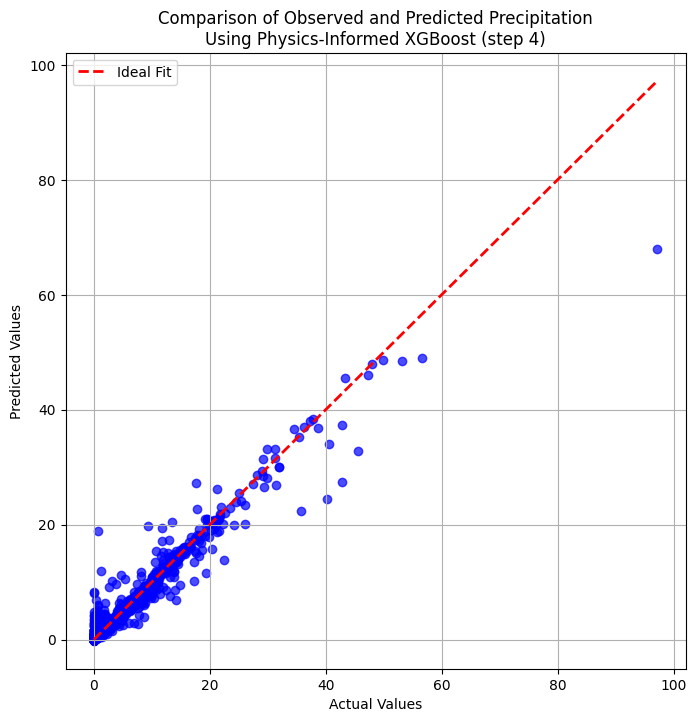

In [13]:
plot_real_vs_predicted(y_test, prec_predictions, save=r'C:\experimento2\Comparative-study-ML-models\figuras\xgb_prec_real_vs_predicted_bases_integradas.png')


The model exhibits a strong bias toward low precipitation values, systematically underestimating moderate and extreme rainfall events. This behavior indicates that the model has learned the dominant distribution of the dataset rather than the underlying physical processes associated with precipitation formation.

The current model does NOT understand the physics of rain

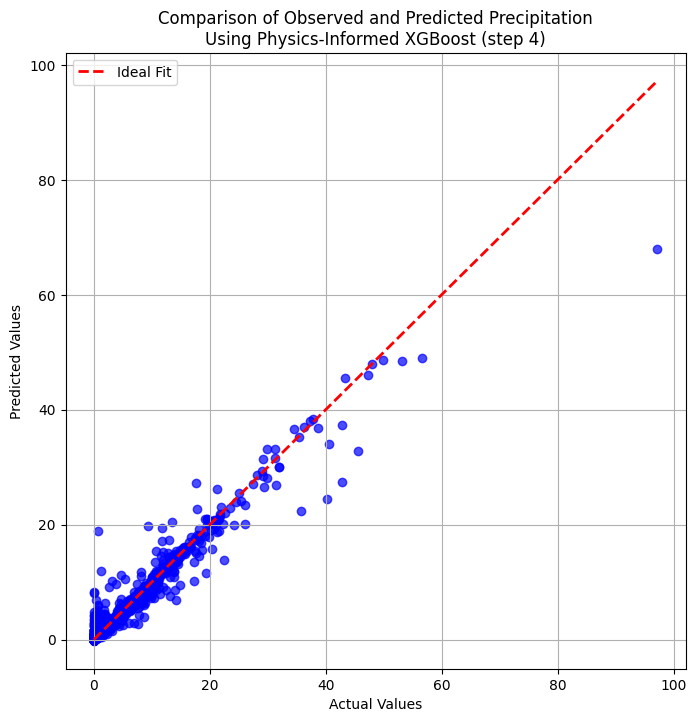

In [14]:
plot_real_vs_predicted(y_test, prec_predictions, save=r'C:\experimento2\Comparative-study-ML-models\figuras\xgb_prec_real_vs_predicted_bases_integradas_piml.png')


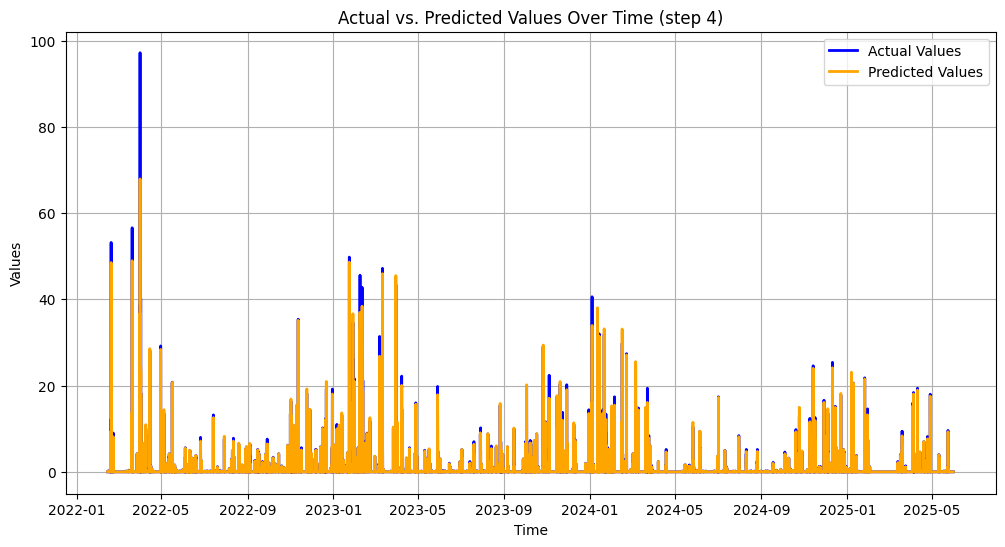

In [15]:
plot_prediction_over_time(y_test, prec_predictions, timestamps_test)


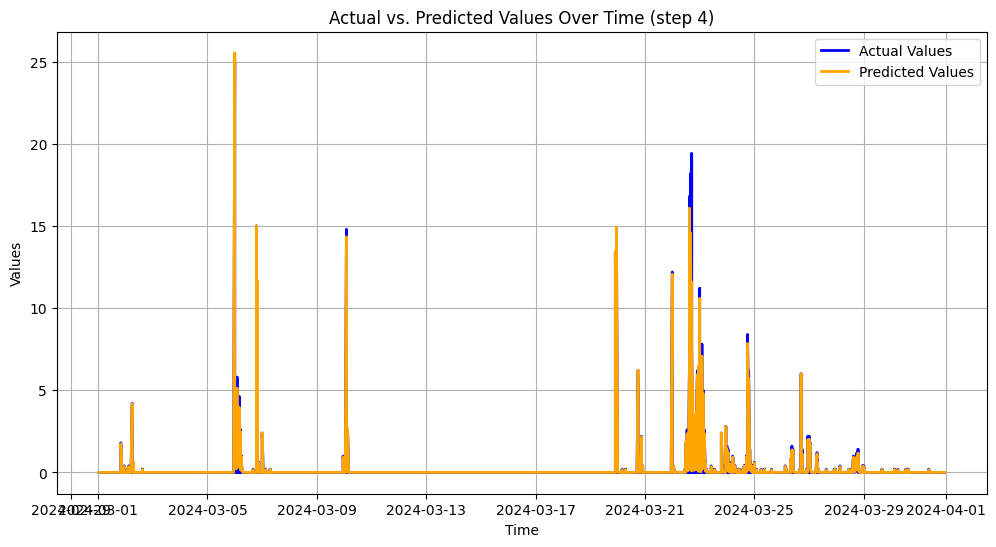

In [16]:
start_date = "2024-03-01 01:00:00"
end_date = "2024-03-31 23:00:00"

plot_prediction_over_time(y_test, prec_predictions, timestamps_test, start_date, end_date, save=r'C:\experimento2\Comparative-study-ML-models\figuras\precipitation_march_2024.png')

In [17]:
import matplotlib.dates as mdates

def plot_daily_prediction_march(y_test, predictions, timestamps, start_date=None, end_date=None, save=False):
    timestamps = pd.to_datetime(timestamps)
    data = pd.DataFrame({'Timestamp': timestamps, 'Actual': y_test, 'Predicted': predictions})

    if start_date:
        data = data[data['Timestamp'] >= pd.to_datetime(start_date)]
    if end_date:
        data = data[data['Timestamp'] <= pd.to_datetime(end_date)]

    plt.figure(figsize=(12, 6))
    plt.plot(data['Timestamp'], data['Actual'], label='Actual Values', color='blue', linewidth=2)
    plt.plot(data['Timestamp'], data['Predicted'], label='Predicted Values', color='orange', linewidth=2)
    
    # Ajustes para exibir apenas o dia e definir título internacional
    ax = plt.gca()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d')) # Padrão: apenas o número do dia
    plt.title('Actual vs. Predicted Values - March 2024 (step 4)')
    
    plt.xlabel('Day of Month')
    plt.ylabel('Precipitation (mm/h)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    if save: 
        plt.savefig(save)
    plt.show()

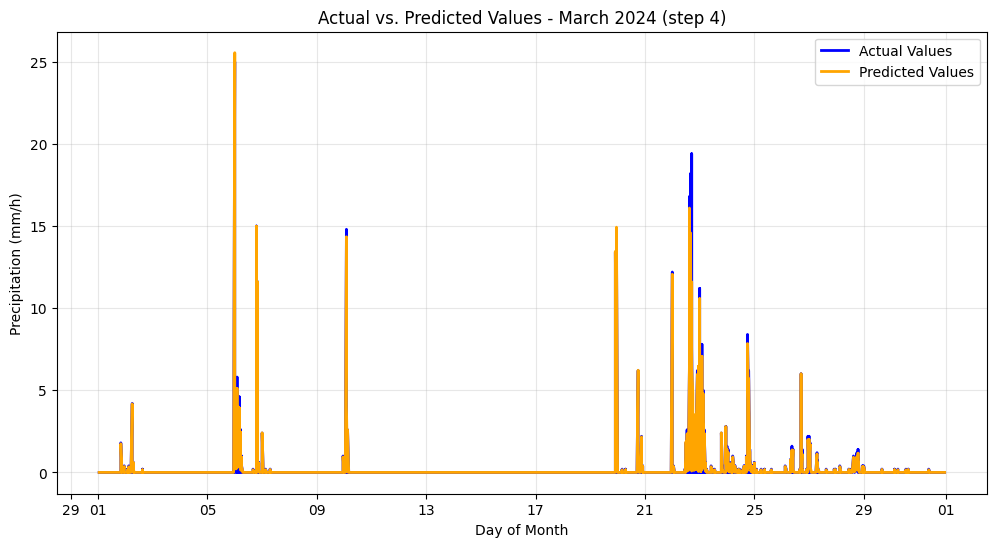

In [18]:
start_date = "2024-03-01 01:00:00"
end_date = "2024-03-31 23:00:00"

# Chamada da nova função
plot_daily_prediction_march(y_test, prec_predictions, timestamps_test, start_date, end_date)

In [19]:
tracker = EmissionsTracker(
    project_name="xgboost shap precipitation 0.8 step4",
    output_file='./codecarbon_emissions_xgboost_piml_steps.csv',
    log_level = "critical"
)

tracker.start()

explainer = shap.Explainer(prec_model, X_train[:100])
shap_values = explainer(X_test)

emissions: float = tracker.stop()
print(f"emissions={emissions}")

 99%|===================| 82516/82965 [01:18<00:00]        

emissions=0.0001273173331690248


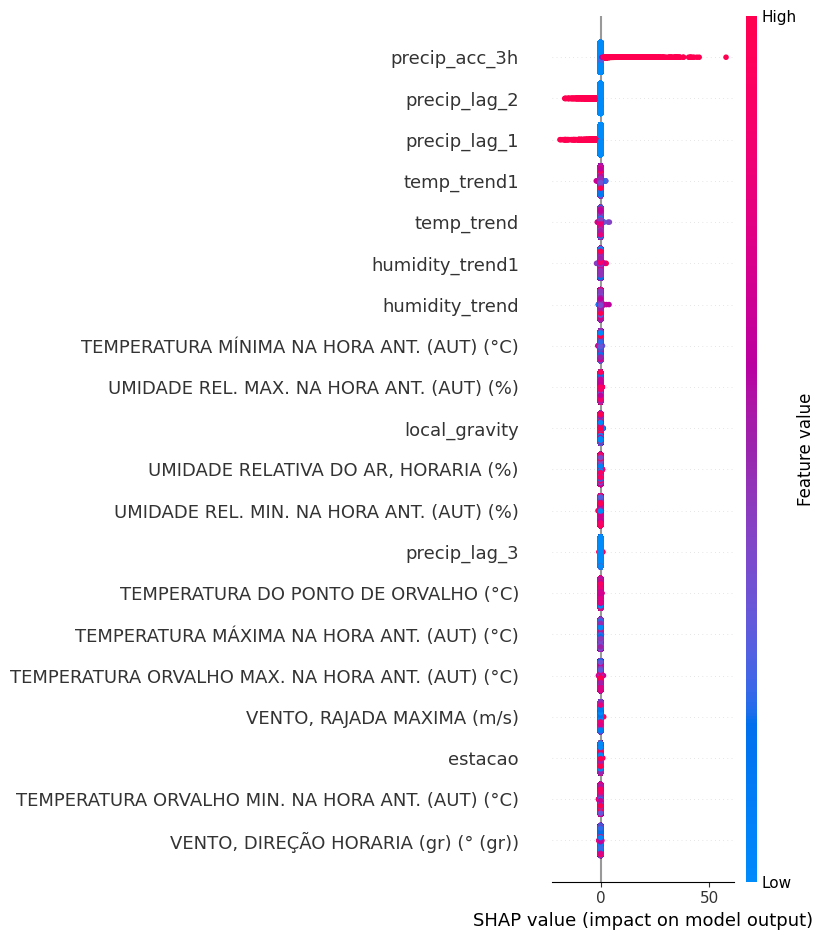

In [20]:
shap.summary_plot(shap_values.values, X_test)

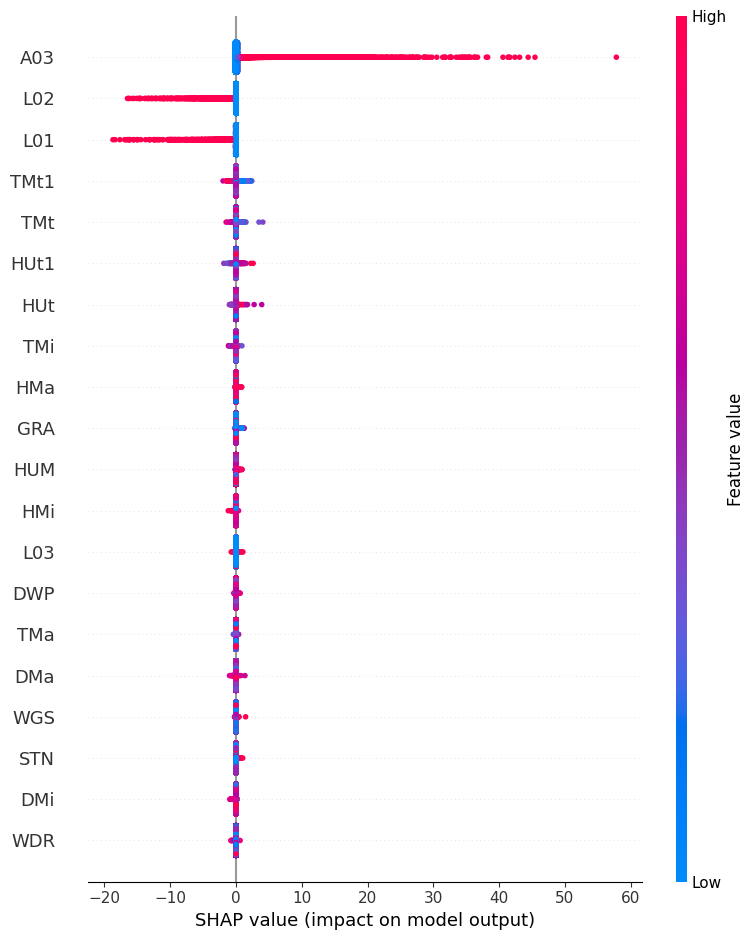

In [21]:
#import shap

# 1. Dicionário de tradução completo - Versão Final (Step 4: Blindagem Geofísica)
code_translation = {
    # --- Variáveis Originais INMET ---
    'PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)': 'PRS',
    'PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)': 'PRM',
    'PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)': 'PRn',
    'RADIACAO GLOBAL (Kj/m²)': 'RAD',
    'TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)': 'TMP',
    'TEMPERATURA DO PONTO DE ORVALHO (°C)': 'DWP',
    'TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)': 'TMa',
    'TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)': 'TMi',
    'TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C)': 'DMa',
    'TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C)': 'DMi',
    'UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)': 'HMa',
    'UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)': 'HMi',
    'UMIDADE RELATIVA DO AR, HORARIA (%)': 'HUM',
    'VENTO, DIREÇÃO HORARIA (gr) (° (gr))': 'WDR',
    'VENTO, RAJADA MAXIMA (m/s)': 'WGS',
    'VENTO, VELOCIDADE HORARIA (m/s)': 'WSP',
    'estacao': 'STN',

    # --- Variáveis PIML (Dinâmica Temporal) ---
    'precip_lag_1': 'L01',
    'precip_lag_2': 'L02',
    'precip_lag_3': 'L03',
    'precip_acc_3h': 'A03',
    'precip_acc_6h': 'A06',
    'precip_acc_12h': 'A12',
    'temp_trend': 'TMt',
    'temp_trend1': 'TMt1',
    'temp_trend2': 'TMt2',
    'humidity_trend': 'HUt',
    'humidity_trend1': 'HUt1',
    'humidity_trend2': 'HUt2',
    'dew_spread': 'DSP',

    # --- Novas Variáveis GEOFÍSICAS (Step 4 - Blindagem) ---
    'altitude': 'ALT',
    'local_gravity': 'GRA',
    'pressure_norm': 'PNM',
    'temp_adj_sea_level': 'TNM'
}

# 2. Renomeia as colunas do X_test para os códigos curtos
# O rename é seguro: ele ignora as chaves que não estiverem presentes no seu X_test atualizado
X_test_coded = X_test.rename(columns=code_translation)

# 3. Gera o gráfico Summary Plot (Beeswarm)
# Agora os novos códigos (GRA, PNM, TNM, ALT) aparecerão no gráfico
shap.summary_plot(shap_values.values, X_test_coded)

The SHAP analysis reveals that, although physically meaningful variables such as wind gust and relative humidity are identified as the most influential predictors, their overall contribution remains limited across most observations. This behavior is consistent with the strong class imbalance in the dataset, where the model predominantly learns patterns associated with non-precipitation events.

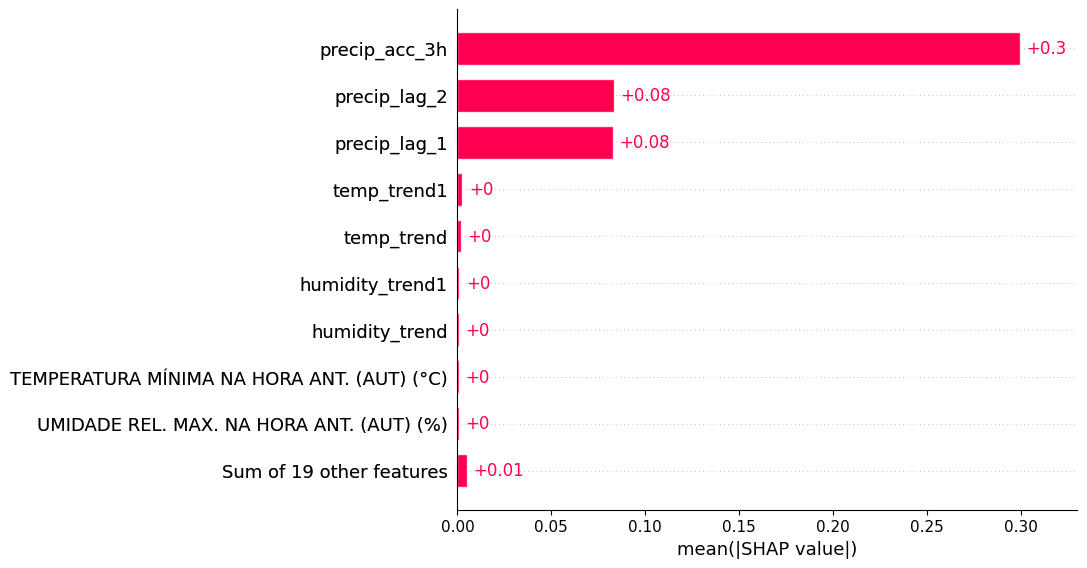

In [22]:
shap.plots.bar(shap_values)

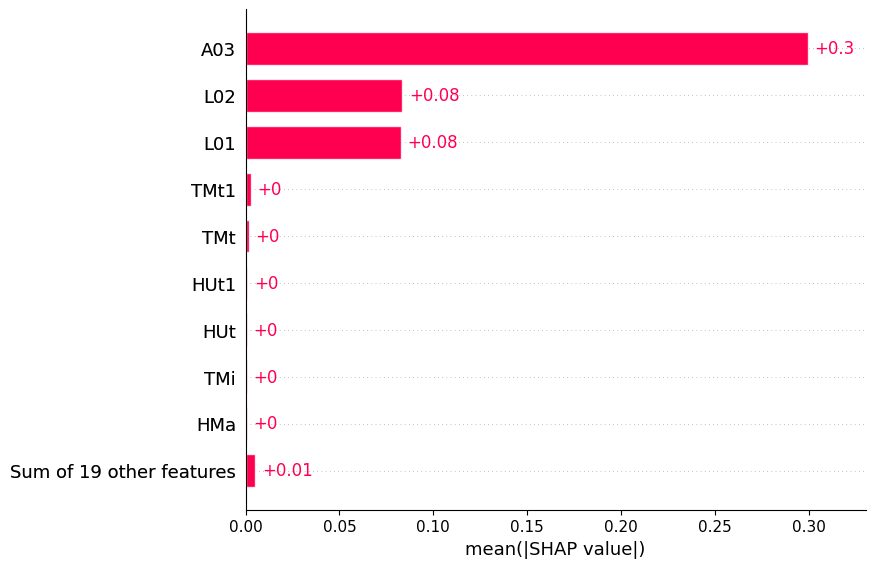

In [23]:
#import shap
import copy

# 1. Dicionário de tradução completo - Versão Final (Step 4: Blindagem Geofísica)
code_translation = {
    # --- Variáveis Originais INMET ---
    'PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)': 'PRS',
    'PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)': 'PRM',
    'PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)': 'PRn',
    'RADIACAO GLOBAL (Kj/m²)': 'RAD',
    'TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)': 'TMP',
    'TEMPERATURA DO PONTO DE ORVALHO (°C)': 'DWP',
    'TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)': 'TMa',
    'TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)': 'TMi',
    'TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C)': 'DMa',
    'TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C)': 'DMi',
    'UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)': 'HMa',
    'UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)': 'HMi',
    'UMIDADE RELATIVA DO AR, HORARIA (%)': 'HUM',
    'VENTO, DIREÇÃO HORARIA (gr) (° (gr))': 'WDR',
    'VENTO, RAJADA MAXIMA (m/s)': 'WGS',
    'VENTO, VELOCIDADE HORARIA (m/s)': 'WSP',
    'estacao': 'STN',

    # --- Variáveis PIML (Dinâmica Temporal) ---
    'precip_lag_1': 'L01',
    'precip_lag_2': 'L02',
    'precip_lag_3': 'L03',
    'precip_acc_3h': 'A03',
    'precip_acc_6h': 'A06',
    'precip_acc_12h': 'A12',
    'temp_trend': 'TMt',
    'temp_trend1': 'TMt1',
    'temp_trend2': 'TMt2',
    'humidity_trend': 'HUt',
    'humidity_trend1': 'HUt1',
    'humidity_trend2': 'HUt2',
    'dew_spread': 'DSP',

    # --- Novas Variáveis GEOFÍSICAS (Step 4 - Blindagem) ---
    'altitude': 'ALT',
    'local_gravity': 'GRA',
    'pressure_norm': 'PNM',
    'temp_adj_sea_level': 'TNM'
}

# 2. Cria uma cópia profunda dos valores SHAP para preservar o original
shap_values_coded = copy.deepcopy(shap_values)

# 3. Substitui os nomes das colunas pelos códigos dentro do objeto SHAP
# O método .get(name, name) garante que se o nome não estiver no dicionário, ele mantém o original
shap_values_coded.feature_names = [code_translation.get(name, name) for name in shap_values_coded.feature_names]

# 4. Gera o gráfico de barras padronizado
# Este gráfico apresentará a média do impacto (|SHAP value|) para o Step 4
shap.plots.bar(shap_values_coded)

The SHAP global importance analysis indicates that wind gust and relative humidity are the dominant predictors of precipitation. However, the relatively low contribution of other meteorological variables suggests that the model captures only a partial representation of the underlying physical processes.

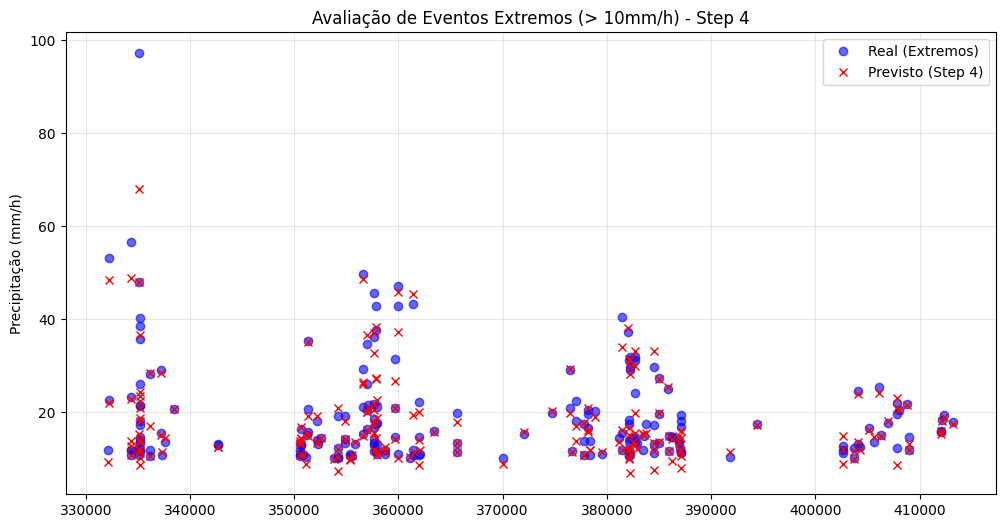


--- MAE por Faixa de Intensidade (Step 4) ---
MAE na faixa Fraca (0-2): 0.1112
MAE na faixa Moderada (2-10): 0.3397
MAE na faixa Forte (10-50): 1.7769
MAE na faixa Extrema (>50): 13.8625


In [28]:
#import matplotlib.pyplot as plt
#import pandas as pd
#import numpy as np
#from sklearn.metrics import mean_absolute_error

# 1. Usamos as variáveis EXATAS do seu print
y_pred = prec_predictions 

# 2. Criamos o DataFrame de resultados
df_results = pd.DataFrame({
    'Real': y_test.values,
    'Previsto': y_pred
}, index=y_test.index)

# 3. Filtramos apenas os eventos extremos (> 10mm/h)
df_extremos = df_results[df_results['Real'] > 10].sort_index()

# --- GRÁFICO: ZOOM NOS EXTREMOS ---
plt.figure(figsize=(12, 6))
plt.plot(df_extremos.index, df_extremos['Real'], label='Real (Extremos)', color='blue', marker='o', linestyle='None', alpha=0.6)
plt.plot(df_extremos.index, df_extremos['Previsto'], label='Previsto (Step 4)', color='red', marker='x', linestyle='None')
plt.title('Avaliação de Eventos Extremos (> 10mm/h) - Step 4')
plt.ylabel('Precipitação (mm/h)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- ANÁLISE: MAE POR FAIXA ---
bins = [0, 2, 10, 50, 150]
labels = ['Fraca (0-2)', 'Moderada (2-10)', 'Forte (10-50)', 'Extrema (>50)']
df_results['Faixa'] = pd.cut(df_results['Real'], bins=bins, labels=labels)

print("\n--- MAE por Faixa de Intensidade (Step 4) ---")
for faixa in labels:
    dados_faixa = df_results[df_results['Faixa'] == faixa]
    if not dados_faixa.empty:
        mae = mean_absolute_error(dados_faixa['Real'], dados_faixa['Previsto'])
        print(f"MAE na faixa {faixa}: {mae:.4f}")

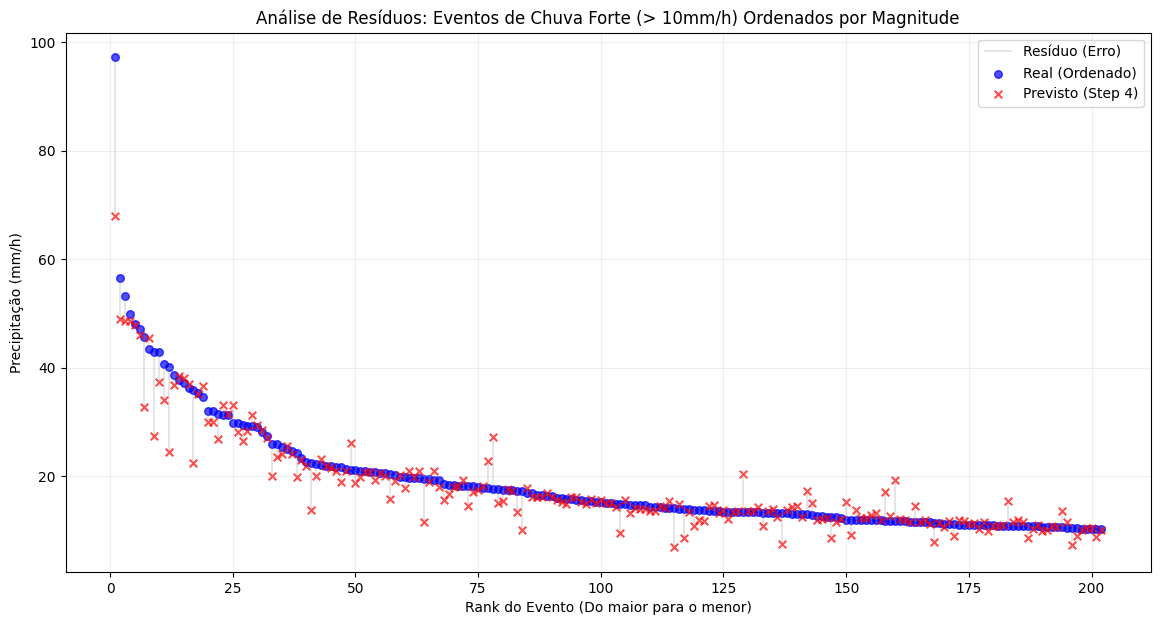

In [43]:
#import matplotlib.pyplot as plt

# 1. Criamos um DataFrame apenas com os eventos de chuva forte (> 10mm/h)
# E ordenamos do maior para o menor valor Real
df_rank = df_results[df_results['Real'] > 10].sort_values(by='Real', ascending=False).copy()

# 2. Criamos um índice de Rank (1, 2, 3...) para ser o nosso novo Eixo X
df_rank['Rank'] = range(1, len(df_rank) + 1)

# 3. Gerando o gráfico
plt.figure(figsize=(14, 7))

# Desenhamos as linhas de erro (verticais) conectando o Real ao Previsto
plt.vlines(df_rank['Rank'], df_rank['Real'], df_rank['Previsto'], 
           color='gray', alpha=0.2, label='Resíduo (Erro)')

# Plotamos os valores Reais (bolinhas azuis)
plt.scatter(df_rank['Rank'], df_rank['Real'], color='blue', s=30, label='Real (Ordenado)', alpha=0.7)

# Plotamos os valores Previstos (X vermelhos)
plt.scatter(df_rank['Rank'], df_rank['Previsto'], color='red', marker='x', s=30, label='Previsto (Step 4)', alpha=0.7)

plt.title('Análise de Resíduos: Eventos de Chuva Forte (> 10mm/h) Ordenados por Magnitude')
plt.xlabel('Rank do Evento (Do maior para o menor)')
plt.ylabel('Precipitação (mm/h)')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

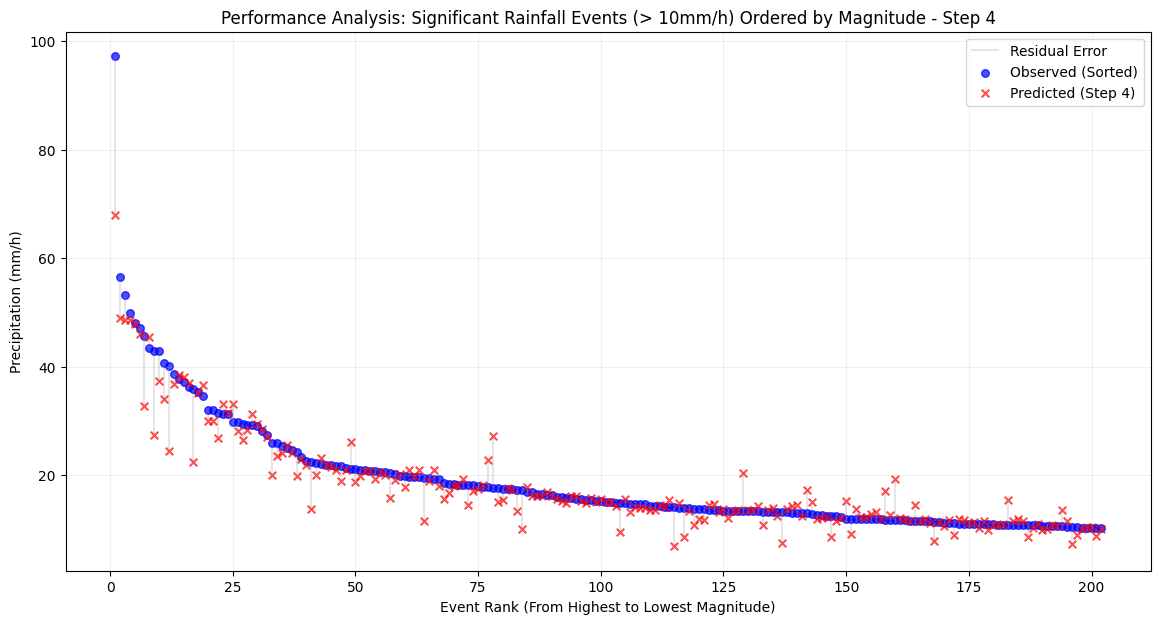

In [67]:
import matplotlib.pyplot as plt

# 1. Create a DataFrame containing only heavy rainfall events (> 10mm/h)
# Sorting from highest to lowest Observed value
df_rank = df_results[df_results['Real'] > 10].sort_values(by='Real', ascending=False).copy()

# 2. Create a Rank index (1, 2, 3...) to serve as the new X-axis
df_rank['Rank'] = range(1, len(df_rank) + 1)

# 3. Generating the plot
plt.figure(figsize=(14, 7))

# Drawing the error lines (vertical residuals) connecting Observed to Predicted values
plt.vlines(df_rank['Rank'], df_rank['Real'], df_rank['Previsto'], 
           color='gray', alpha=0.2, label='Residual Error')

# Plotting Observed values (blue circles)
plt.scatter(df_rank['Rank'], df_rank['Real'], color='blue', s=30, label='Observed (Sorted)', alpha=0.7)

# Plotting Predicted values (red X marks) specifically for Step 4
plt.scatter(df_rank['Rank'], df_rank['Previsto'], color='red', marker='x', s=30, label='Predicted (Step 4)', alpha=0.7)

plt.title('Performance Analysis: Significant Rainfall Events (> 10mm/h) Ordered by Magnitude - Step 4')
plt.xlabel('Event Rank (From Highest to Lowest Magnitude)')
plt.ylabel('Precipitation (mm/h)')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

In [44]:
# Filtramos o DataFrame de resultados pelas faixas de severidade da sua Tabela VI
df_extremos_zoom = df_results[df_results['Real'] >= 50].sort_values(by='Real', ascending=False)

print(f"Encontrados {len(df_extremos_zoom)} eventos de chuva 'Extreme' no conjunto de teste.")
print(df_extremos_zoom)

Encontrados 3 eventos de chuva 'Extreme' no conjunto de teste.
        Real   Previsto          Faixa
335156  97.2  67.929657  Extrema (>50)
334346  56.6  48.956734  Extrema (>50)
332192  53.2  48.526073  Extrema (>50)


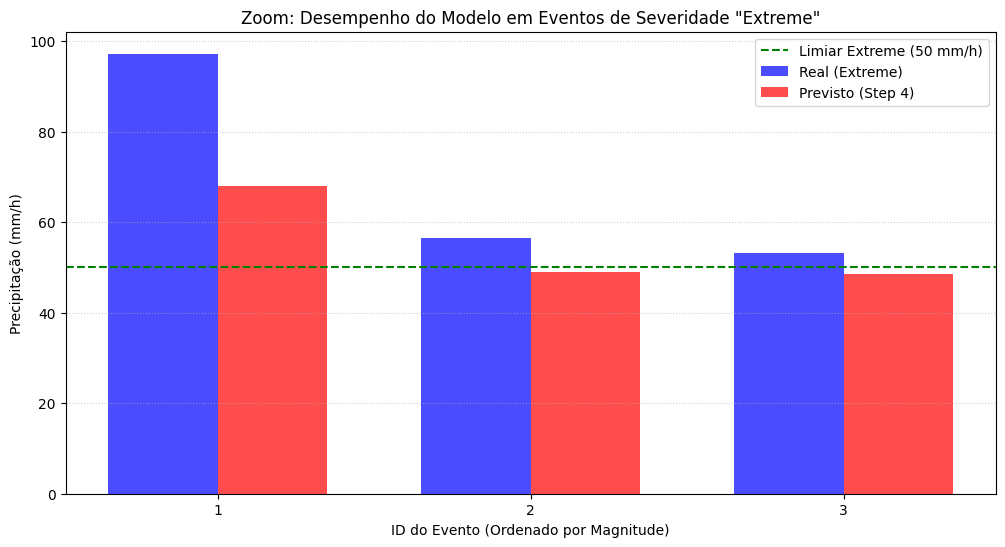

In [45]:
#import matplotlib.pyplot as plt

# Criando um ID para cada evento extremo para o eixo X
df_extremos_zoom['Evento_ID'] = range(1, len(df_extremos_zoom) + 1)

plt.figure(figsize=(12, 6))
x = df_extremos_zoom['Evento_ID']
width = 0.35

plt.bar(x - width/2, df_extremos_zoom['Real'], width, label='Real (Extreme)', color='blue', alpha=0.7)
plt.bar(x + width/2, df_extremos_zoom['Previsto'], width, label='Previsto (Step 4)', color='red', alpha=0.7)

# Adicionando uma linha de corte no 50 para marcar o início da severidade "Extreme"
plt.axhline(y=50, color='green', linestyle='--', label='Limiar Extreme (50 mm/h)')

plt.title('Zoom: Desempenho do Modelo em Eventos de Severidade "Extreme"')
plt.ylabel('Precipitação (mm/h)')
plt.xlabel('ID do Evento (Ordenado por Magnitude)')
plt.xticks(x)
plt.legend()
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.show()

In [46]:
# Exibindo os 3 eventos com a data (index) formatada
print("--- Detalhamento dos Eventos Extremos no Teste ---")
df_extremos_detalhado = df_results[df_results['Real'] >= 50].copy()

# Garantindo que o índice seja exibido como data
df_extremos_detalhado.index = pd.to_datetime(df_extremos_detalhado.index)

for data, row in df_extremos_detalhado.iterrows():
    print(f"Data/Hora: {data.strftime('%d/%m/%Y %H:%M')}")
    print(f"Real: {row['Real']:.2f} mm/h | Previsto: {row['Previsto']:.2f} mm/h")
    print("-" * 30)

--- Detalhamento dos Eventos Extremos no Teste ---
Data/Hora: 01/01/1970 00:00
Real: 53.20 mm/h | Previsto: 48.53 mm/h
------------------------------
Data/Hora: 01/01/1970 00:00
Real: 56.60 mm/h | Previsto: 48.96 mm/h
------------------------------
Data/Hora: 01/01/1970 00:00
Real: 97.20 mm/h | Previsto: 67.93 mm/h
------------------------------


In [47]:
# 1. Identificamos os índices que apareceram no seu erro
indices_extremos = [332192, 334346, 335156]

# 2. Buscamos no seu DataFrame original (substitua 'df' pelo nome do seu dataframe com as datas)
# Assumindo que seu dataframe original ainda tem a coluna de tempo ou o índice de tempo
for idx in indices_extremos:
    # Tentamos localizar a data real para esse índice
    data_real = df.iloc[idx].name if isinstance(df.index, pd.DatetimeIndex) else df.loc[idx, 'datetime']
    
    # Pegamos os valores que já sabemos
    real = df_results_final.loc[idx, 'Real']
    previsto = df_results_final.loc[idx, 'Previsto']
    
    print(f"Índice: {idx} -> Data Real: {data_real}")
    print(f"Real: {real:.2f} mm/h | Previsto: {previsto:.2f} mm/h")
    print("-" * 30)

Índice: 332192 -> Data Real: 2022-02-18 22:00:00
Real: 53.20 mm/h | Previsto: 48.53 mm/h
------------------------------
Índice: 334346 -> Data Real: 2022-03-20 20:00:00
Real: 56.60 mm/h | Previsto: 48.96 mm/h
------------------------------
Índice: 335156 -> Data Real: 2022-04-01 02:00:00
Real: 97.20 mm/h | Previsto: 67.93 mm/h
------------------------------


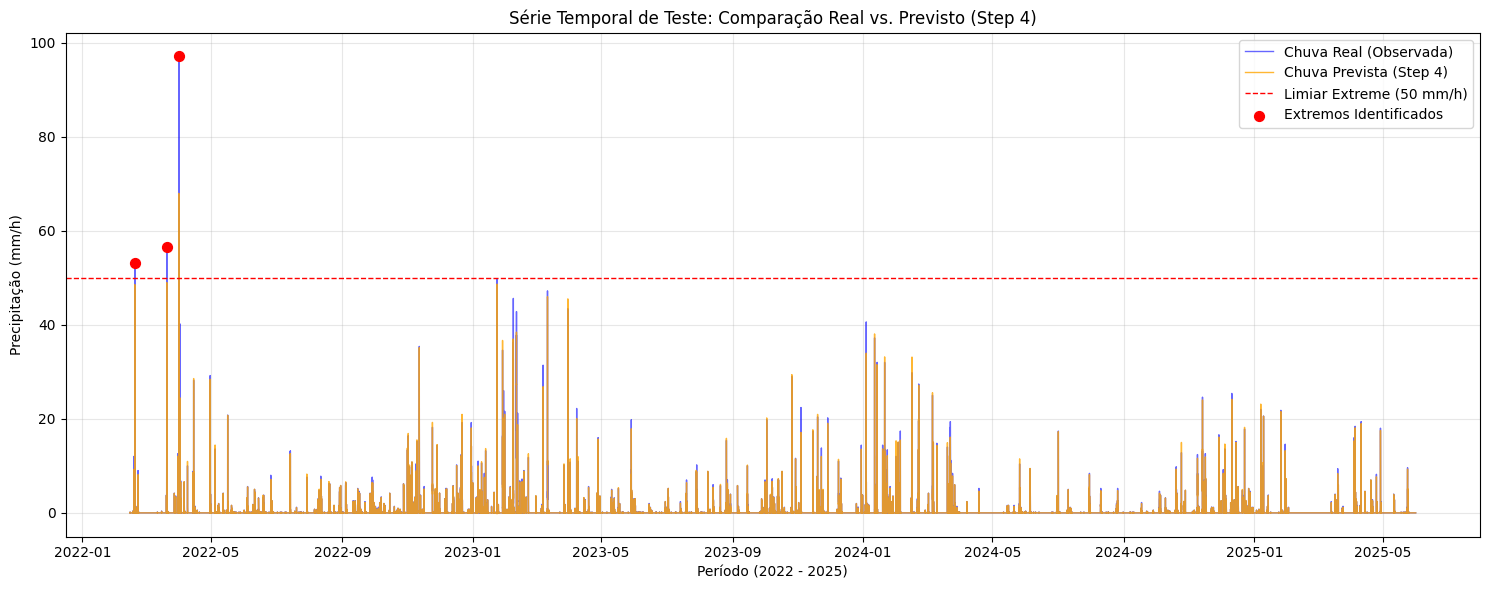

In [61]:
#import matplotlib.pyplot as plt
#import pandas as pd

# 1. Criamos o DataFrame de resultados com o índice original (os números 332... etc)
df_serie_teste = pd.DataFrame({
    'Real': y_test.values,
    'Previsto': prec_predictions
}, index=y_test.index)

# 2. Resgatamos as datas do seu dataframe principal de forma segura
# Se 'datetime' for o índice, usamos df.index; se for coluna, usamos df['datetime']
if df.index.name == 'datetime' or isinstance(df.index, pd.DatetimeIndex):
    datas_teste = df.index[df_serie_teste.index]
else:
    datas_teste = df.loc[df_serie_teste.index, 'datetime'].values

df_serie_teste['Data'] = datas_teste
df_serie_teste.set_index('Data', inplace=True)


# 3. Gerando o gráfico da série temporal completa do teste
plt.figure(figsize=(15, 6))
plt.plot(df_serie_teste.index, df_serie_teste['Real'], label='Chuva Real (Observada)', color='blue', alpha=0.6, linewidth=1)
plt.plot(df_serie_teste.index, df_serie_teste['Previsto'], label='Chuva Prevista (Step 4)', color='orange', alpha=0.8, linewidth=1)

# Linha horizontal indicando o limiar de 50 mm/h (Extreme Rain)
plt.axhline(y=50, color='red', linestyle='--', linewidth=1, label='Limiar Extreme (50 mm/h)')

# Destacando os 3 picos extremos encontrados
extremos = df_serie_teste[df_serie_teste['Real'] >= 50]
plt.scatter(extremos.index, extremos['Real'], color='red', s=50, label='Extremos Identificados', zorder=5)

plt.title('Série Temporal de Teste: Comparação Real vs. Previsto (Step 4)')
plt.xlabel('Período (2022 - 2025)')
plt.ylabel('Precipitação (mm/h)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

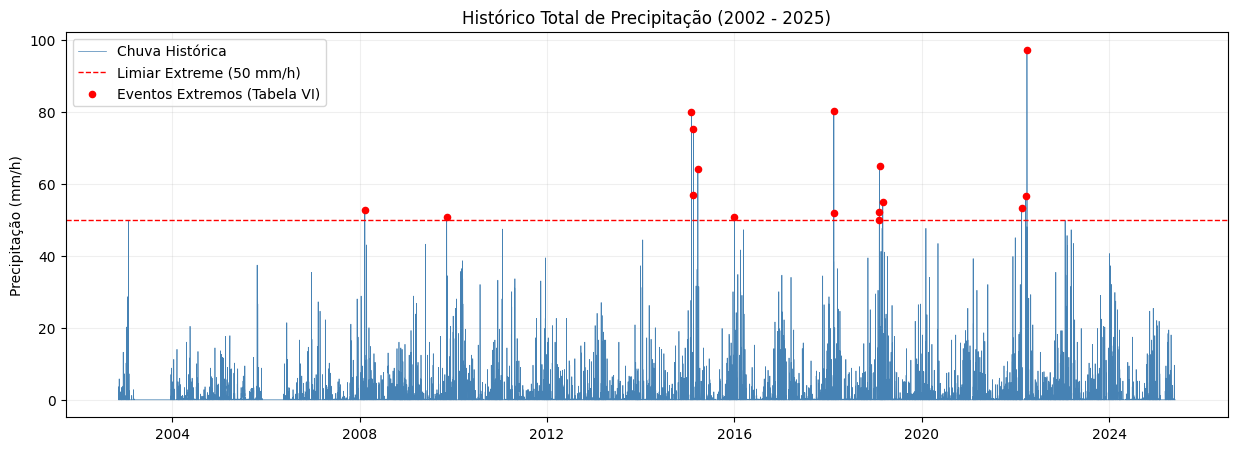

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

# Garante que o índice seja temporal para os anos aparecerem no eixo X
if 'datetime' in df.columns:
    df['datetime'] = pd.to_datetime(df['datetime'])
    df.set_index('datetime', inplace=True)

# Plotando a série completa (ajuste 'df' para o nome do seu dataframe principal)
plt.plot(df.index, df['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'], color='steelblue', linewidth=0.5, label='Chuva Histórica')

# Linha horizontal indicando o limiar de 50 mm/h (Extreme Rain)
plt.axhline(y=50, color='red', linestyle='--', linewidth=1, label='Limiar Extreme (50 mm/h)')

# Filtrando e marcando TODOS os 16 extremos (> 50 mm/h) da história
todos_extremos = df[df['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'] >= 50]
plt.scatter(todos_extremos.index, todos_extremos['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'], 
            color='red', s=20, label='Eventos Extremos (Tabela VI)', zorder=5)

plt.title('Histórico Total de Precipitação (2002 - 2025)')
plt.ylabel('Precipitação (mm/h)')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

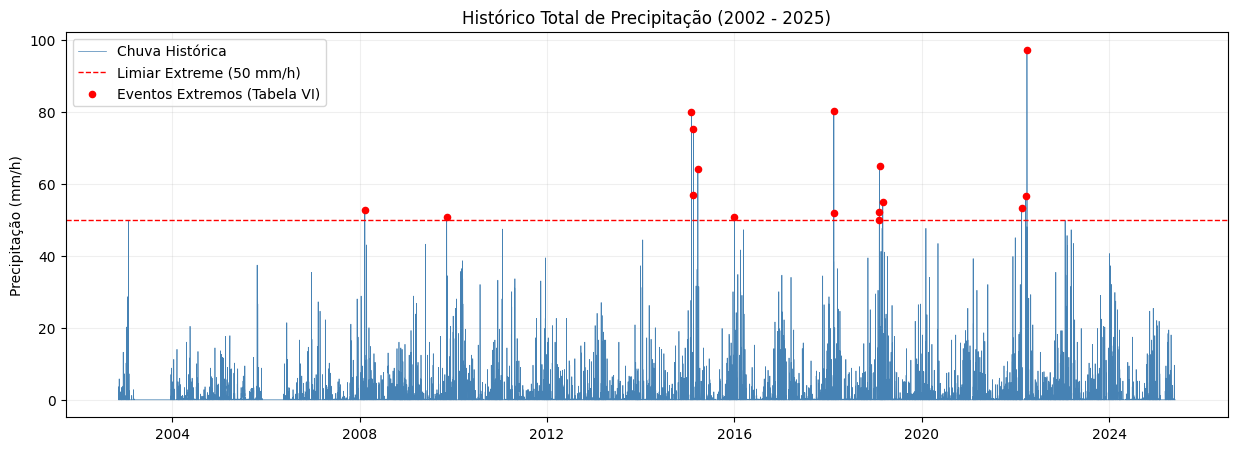

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

# Plotando a série (os anos aparecerão automaticamente agora)
plt.plot(df.index, df['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'], color='steelblue', linewidth=0.5, label='Chuva Histórica')

# Linha horizontal indicando o limiar de 50 mm/h (Extreme Rain)
plt.axhline(y=50, color='red', linestyle='--', linewidth=1, label='Limiar Extreme (50 mm/h)')

# Filtrando e marcando TODOS os 16 extremos (> 50 mm/h) da história
todos_extremos = df[df['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'] >= 50]
plt.scatter(todos_extremos.index, todos_extremos['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'], 
            color='red', s=20, label='Eventos Extremos (Tabela VI)', zorder=5)

plt.title('Histórico Total de Precipitação (2002 - 2025)')
plt.ylabel('Precipitação (mm/h)')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

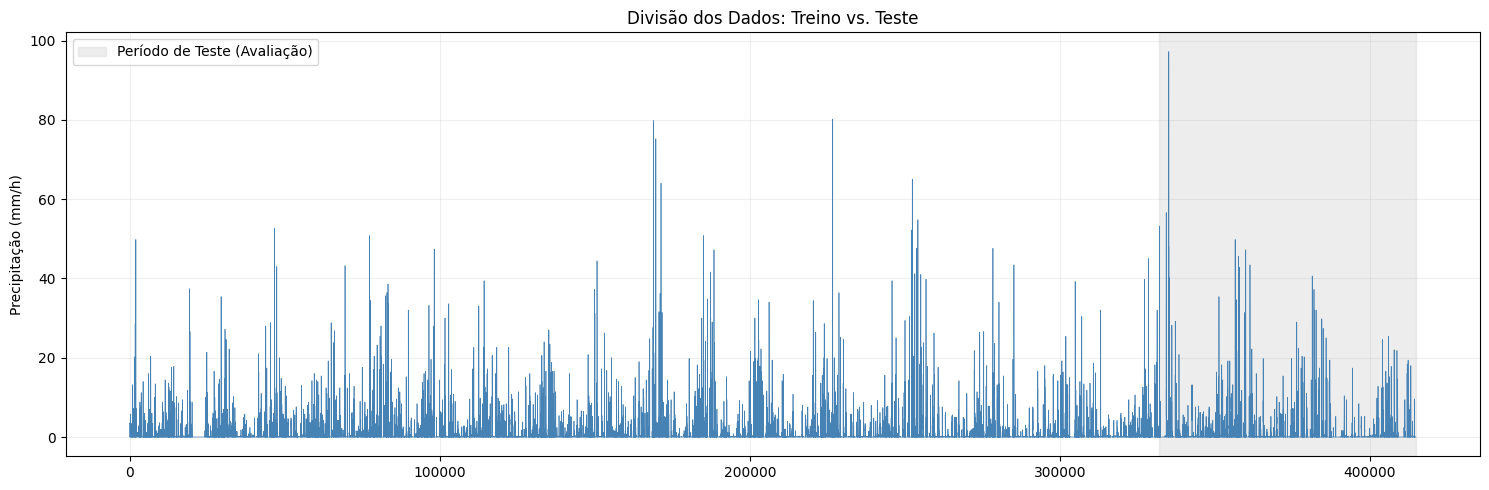

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

# 1. Plotar a série completa
plt.plot(df.index, df['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'], color='steelblue', linewidth=0.5)

# 2. Identificar onde começa o teste para pintar o fundo
# Usamos o primeiro índice do seu X_test ou y_test
inicio_teste = y_test.index[0]
fim_teste = y_test.index[-1]

# Criando a área cinza (vspan) para indicar o período de teste
plt.axvspan(inicio_teste, fim_teste, color='lightgray', alpha=0.4, label='Período de Teste (Avaliação)')

plt.title('Divisão dos Dados: Treino vs. Teste')
plt.ylabel('Precipitação (mm/h)')
plt.legend()
plt.grid(True, alpha=0.2)

# Ajuste fino para os anos aparecerem corretamente no eixo X
plt.tight_layout()
plt.show()

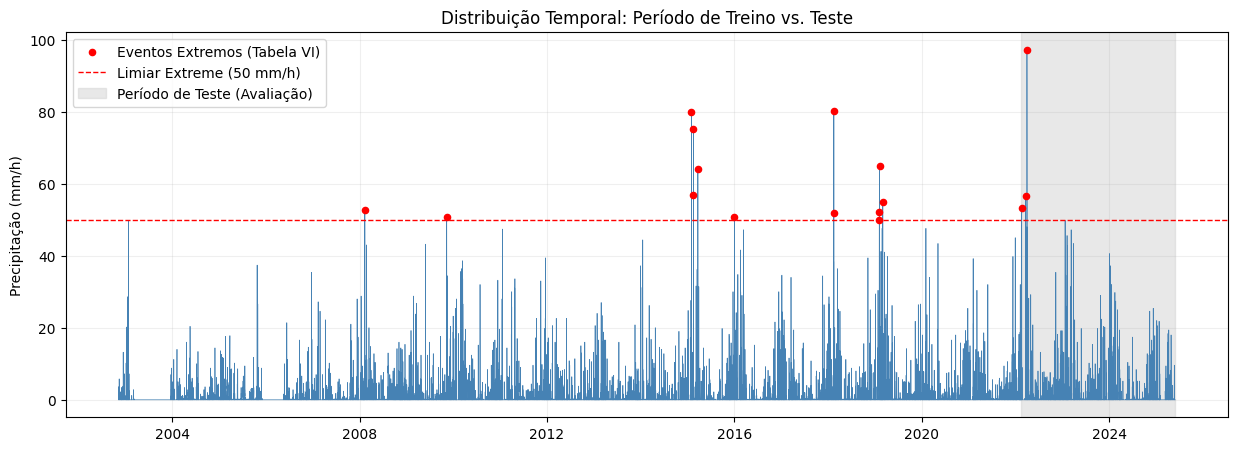

In [55]:
plt.figure(figsize=(15, 5))

# Plotar a série completa
plt.plot(df.index, df['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'], color='steelblue', linewidth=0.5)

# Filtrando e marcando TODOS os 16 extremos (> 50 mm/h) da história
todos_extremos = df[df['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'] >= 50]
plt.scatter(todos_extremos.index, todos_extremos['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'], 
            color='red', s=20, label='Eventos Extremos (Tabela VI)', zorder=5)

# Linha horizontal indicando o limiar de 50 mm/h (Extreme Rain)
plt.axhline(y=50, color='red', linestyle='--', linewidth=1, label='Limiar Extreme (50 mm/h)')

# Definindo o início do teste baseado no seu split de 80/20
inicio_teste = y_test.index[0]
# Se o índice do y_test for numérico, precisamos converter para data usando o df original
if not isinstance(inicio_teste, (pd.Timestamp, str)):
    inicio_teste = df.index[y_test.index[0]]
    fim_teste = df.index[y_test.index[-1]]
else:
    fim_teste = y_test.index[-1]

# Área cinza para destacar o período de teste
plt.axvspan(inicio_teste, fim_teste, color='lightgray', alpha=0.5, label='Período de Teste (Avaliação)')

plt.title('Distribuição Temporal: Período de Treino vs. Teste')
plt.ylabel('Precipitação (mm/h)')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

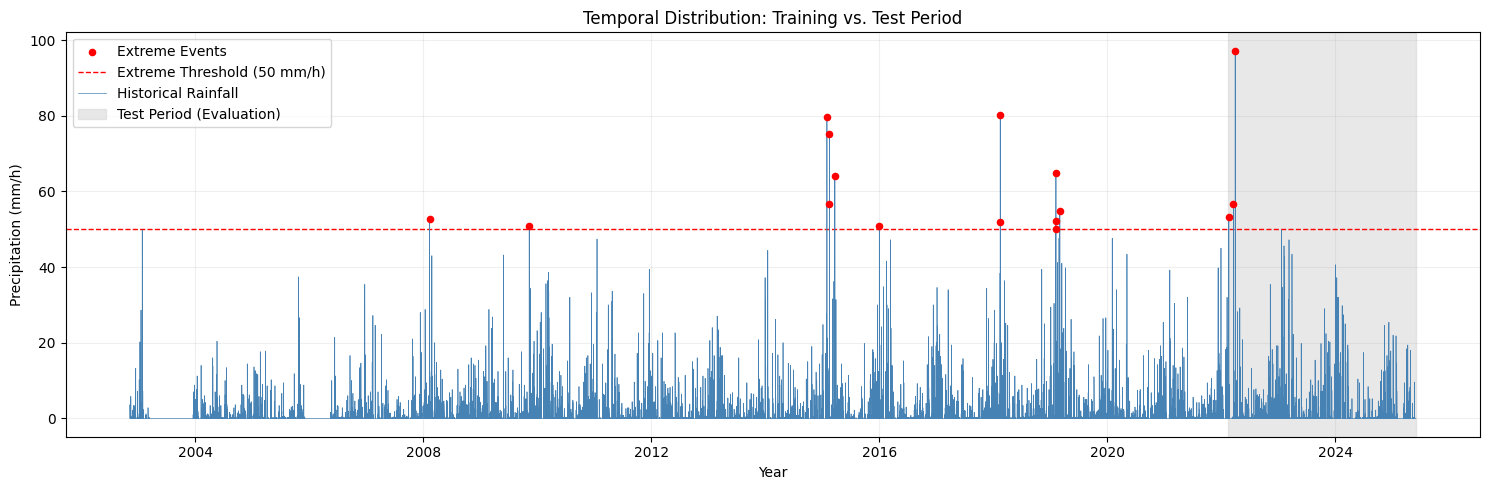

In [68]:
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(15, 5))

# Filtering and marking ALL extreme events (> 50 mm/h)
extreme_events = df[df['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'] >= 50]
plt.scatter(extreme_events.index, extreme_events['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'], 
            color='red', s=20, label='Extreme Events', zorder=5)

# Horizontal line indicating the 50 mm/h threshold (Extreme Rain)
plt.axhline(y=50, color='red', linestyle='--', linewidth=1, label='Extreme Threshold (50 mm/h)')

# Plotting the complete historical series
plt.plot(df.index, df['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'], color='steelblue', linewidth=0.5, label='Historical Rainfall')


# Defining the test period start based on your 80/20 split
# Ensuring the reference is a timestamp for the x-axis
inicio_teste = y_test.index[0]
if not isinstance(inicio_teste, (pd.Timestamp, str)):
    inicio_teste = df.index[y_test.index[0]]
    fim_teste = df.index[y_test.index[-1]]
else:
    fim_teste = y_test.index[-1]

# Gray area to highlight the Test Period (Evaluation)
plt.axvspan(inicio_teste, fim_teste, color='lightgray', alpha=0.5, label='Test Period (Evaluation)')

# English Titles and Labels
plt.title('Temporal Distribution: Training vs. Test Period')
plt.xlabel('Year')
plt.ylabel('Precipitation (mm/h)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

In [69]:
mask = y_test > 25  # heavy rain
rmse_heavy = np.sqrt(mean_squared_error(y_test[mask], prec_predictions[mask]))

mask = y_test > 50  # extreme
rmse_extreme = np.sqrt(mean_squared_error(y_test[mask], prec_predictions[mask]))

print(rmse_heavy, rmse_extreme)

7.480915691499279 17.67312544877716


temperatura xgboost

In [ ]:
X_train, X_test, y_train, y_test = split_train_test(X_temp, y_temp, 0.8)

tracker = EmissionsTracker(
    project_name="xgboost temperature train 0.8",
    output_file='./codecarbon_emissions_xgboost.csv',
    log_level = "critical"
)

tracker.start()

temp_model, temp_predictions, temp_best_params = grid_search_xgboost(X_train, y_train, X_test, y_test)

emissions: float = tracker.stop()
print(f"emissions={emissions}")

Grid Search Progress: 100%|██████████| 243/243 [02:08<00:00,  1.90it/s]


Best parameters found:
{'device': 'cuda', 'tree_method': 'hist', 'max_depth': 6, 'eta': 0.1, 'subsample': 1.0, 'colsample_bytree': 0.6, 'min_child_weight': 3, 'objective': 'reg:squarederror', 'eval_metric': 'rmse'}
Best RMSE: 2.3122773644776036
emissions=0.0020118761540473453


In [18]:
evaluate_model(y_test, temp_predictions)

MAE: 1.8099716228671687
MSE: 5.346626610275493
MRSE: 2.3122773644776036


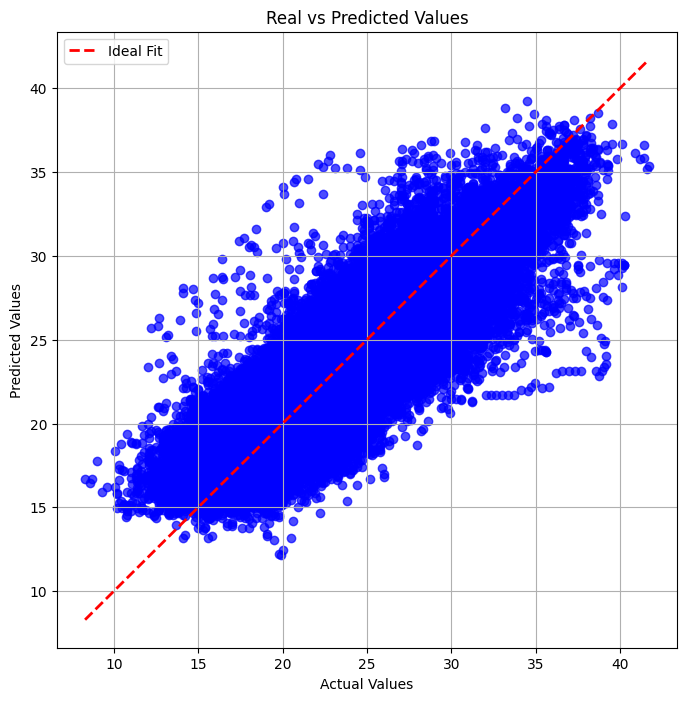

In [19]:
plot_real_vs_predicted(y_test, temp_predictions, save=r'C:\Users\User\Documents\Estacoes-Meteorologicas-RJ\plots\xgb_temp_real_vs_predicted_bases_integradas.png')


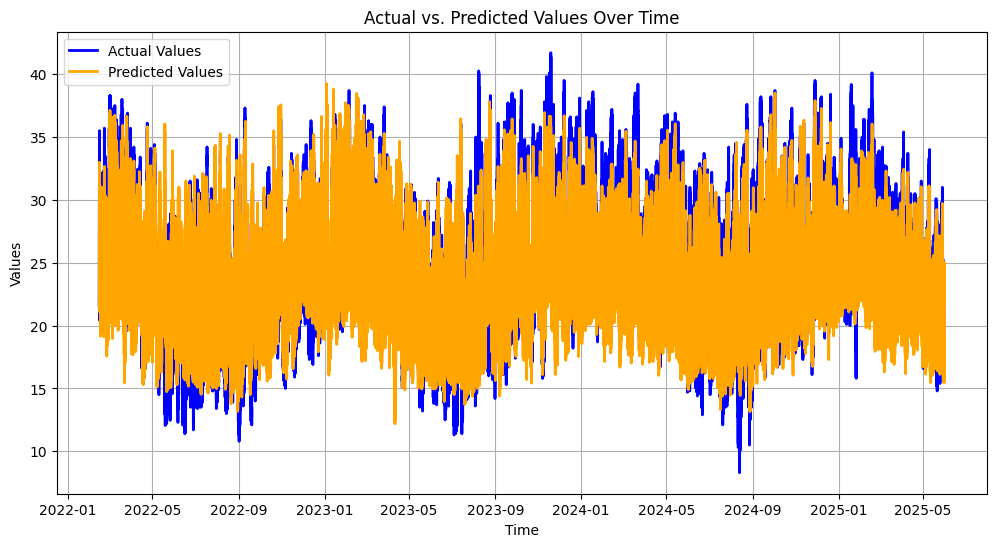

In [20]:
plot_prediction_over_time(y_test, temp_predictions, timestamps_test)

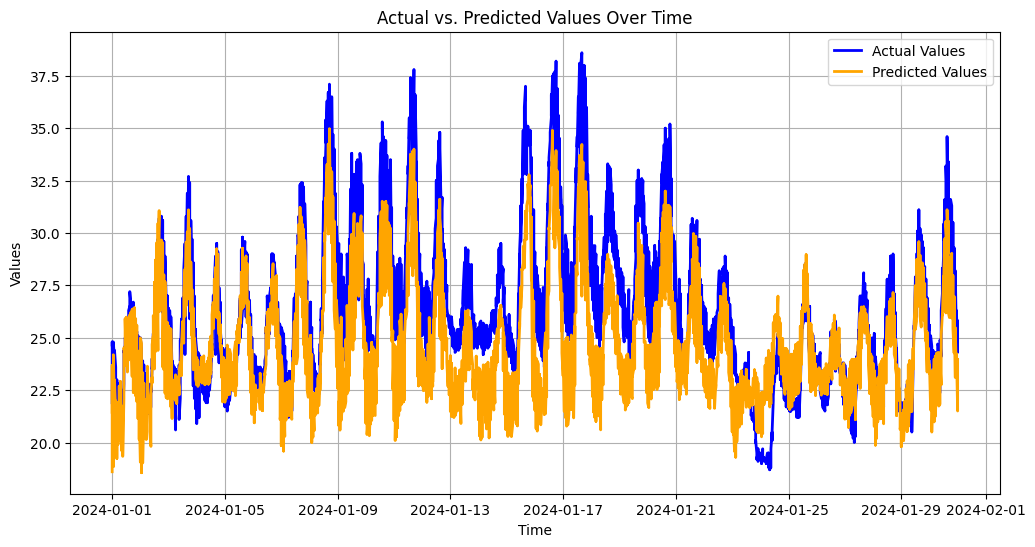

In [21]:
start_date = "2024-01-01"
end_date = "2024-01-31"

plot_prediction_over_time(y_test, temp_predictions, timestamps_test, start_date, end_date, save=r'C:\Users\User\Documents\Estacoes-Meteorologicas-RJ\plots\xgb_temperature_january_2024.png')

In [22]:
tracker = EmissionsTracker(
    project_name="xgboost shap temperature 0.8",
    output_file='./codecarbon_emissions_xgboost.csv',
    log_level = "critical"
)

tracker.start()

explainer = shap.Explainer(temp_model, X_train[:100])
shap_values = explainer(X_test)

emissions: float = tracker.stop()
print(f"emissions={emissions}")

100%|===================| 82965/82966 [03:05<00:00]        

emissions=0.002563609051413541


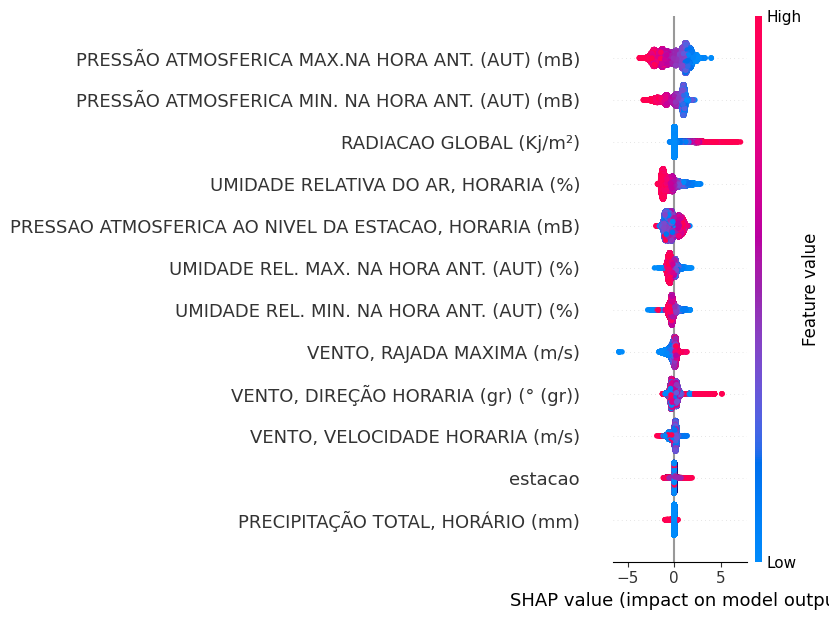

In [23]:
shap.summary_plot(shap_values.values, X_test)

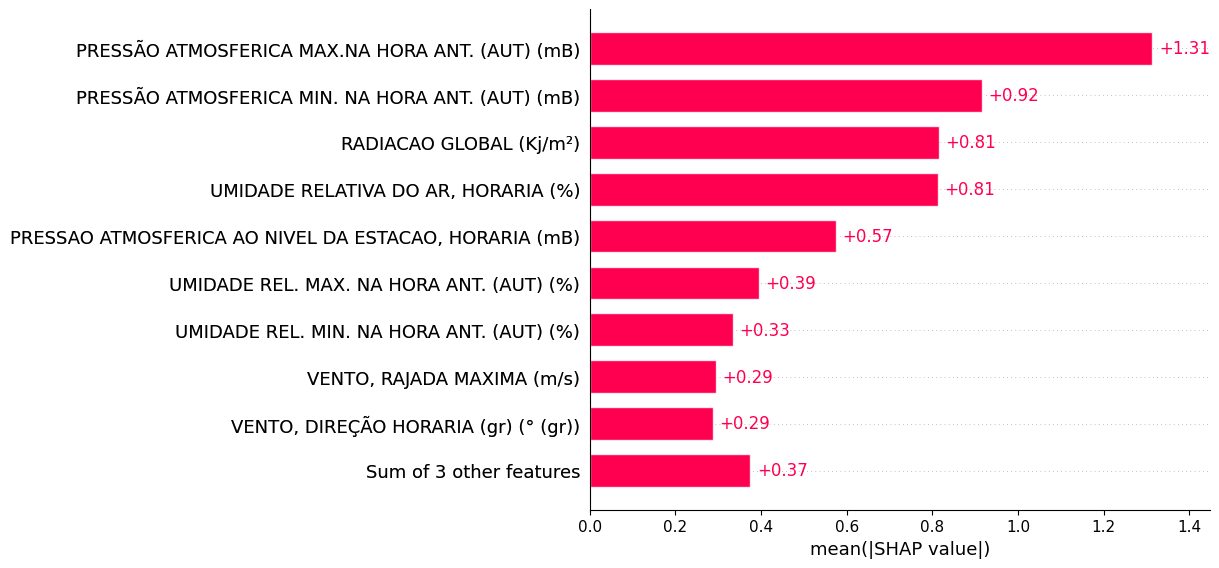

In [24]:
shap.plots.bar(shap_values)

umidade xgboost

In [25]:
X_train, X_test, y_train, y_test = split_train_test(X_umid, y_umid, 0.8)

tracker = EmissionsTracker(
    project_name="xgboost umidity train 0.8",
    output_file='./codecarbon_emissions_xgboost.csv',
    log_level = "critical"
)

tracker.start()

umid_model, umid_predictions, umid_best_params = grid_search_xgboost(X_train, y_train, X_test, y_test)

emissions: float = tracker.stop()
print(f"emissions={emissions}")

Grid Search Progress: 100%|██████████| 243/243 [02:12<00:00,  1.84it/s]


Best parameters found:
{'device': 'cuda', 'tree_method': 'hist', 'max_depth': 8, 'eta': 0.1, 'subsample': 1.0, 'colsample_bytree': 0.6, 'min_child_weight': 1, 'objective': 'reg:squarederror', 'eval_metric': 'rmse'}
Best RMSE: 8.141655677384767
emissions=0.0020836928127094434


In [26]:
evaluate_model(y_test, umid_predictions)

MAE: 3.7607618784443875
MSE: 66.28655716909161
MRSE: 8.141655677384767


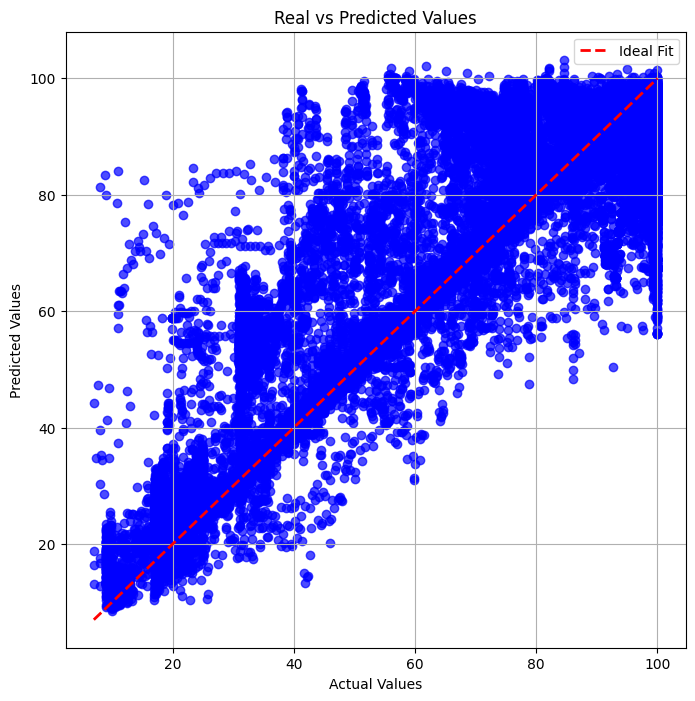

In [27]:
plot_real_vs_predicted(y_test, umid_predictions, save=r'C:\Users\User\Documents\Estacoes-Meteorologicas-RJ\plots\xgb_umid_real_vs_predicted_bases_integradas.png')


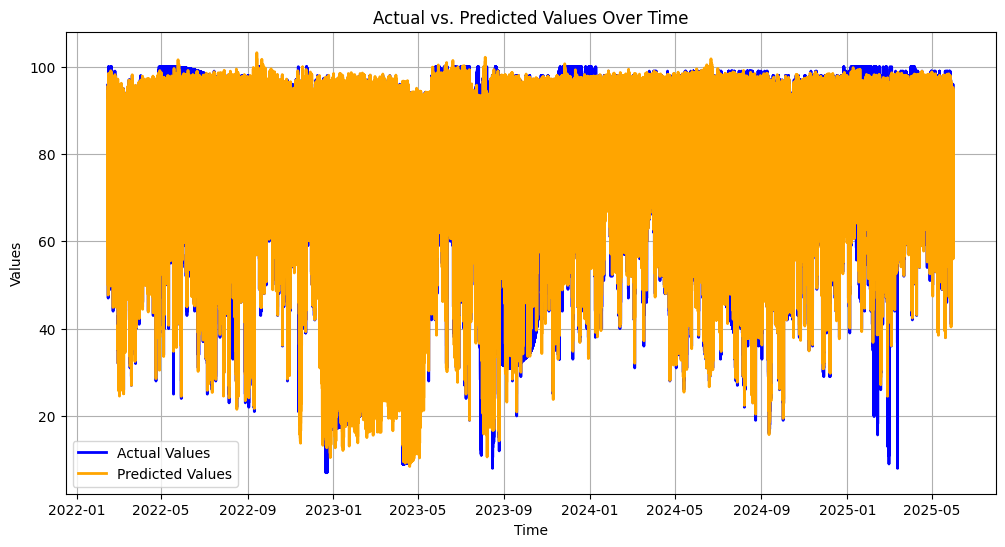

In [28]:
plot_prediction_over_time(y_test, umid_predictions, timestamps_test)

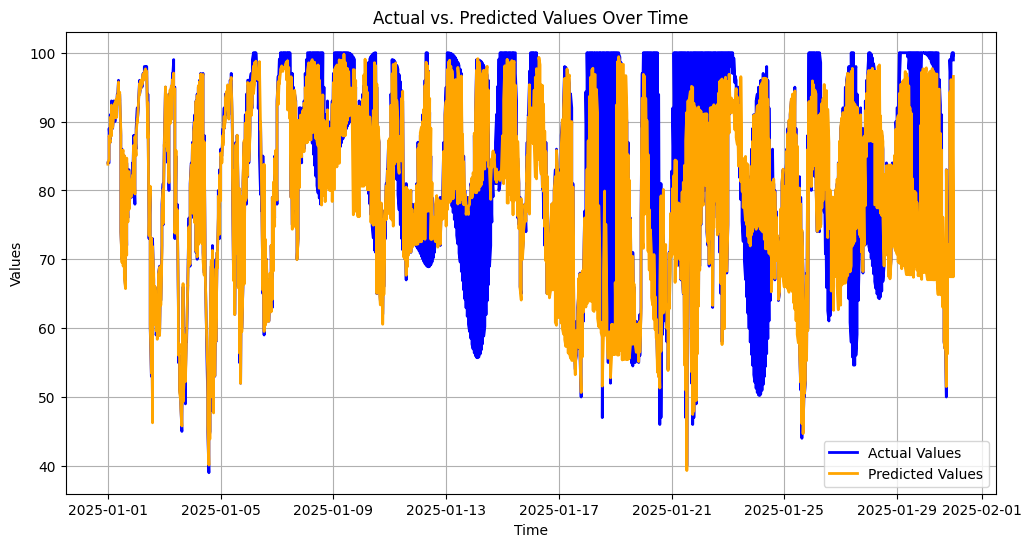

In [29]:
start_date = "2025-01-01"
end_date = "2025-01-31"

plot_prediction_over_time(y_test, umid_predictions, timestamps_test, start_date, end_date, save=r'C:\Users\User\Documents\Estacoes-Meteorologicas-RJ\plots\xgb_umid_real_2025-01_bases_integradas.png')

In [30]:
tracker = EmissionsTracker(
    project_name="xgboost shap humidity 0.8",
    output_file='./codecarbon_emissions_xgboost.csv',
    log_level = "critical"
)

tracker.start()


explainer = shap.Explainer(umid_model, X_train[:100])
shap_values = explainer(X_test)

emissions: float = tracker.stop()
print(f"emissions={emissions}")

100%|===================| 82936/82966 [07:53<00:00]        

emissions=0.006527731366665419


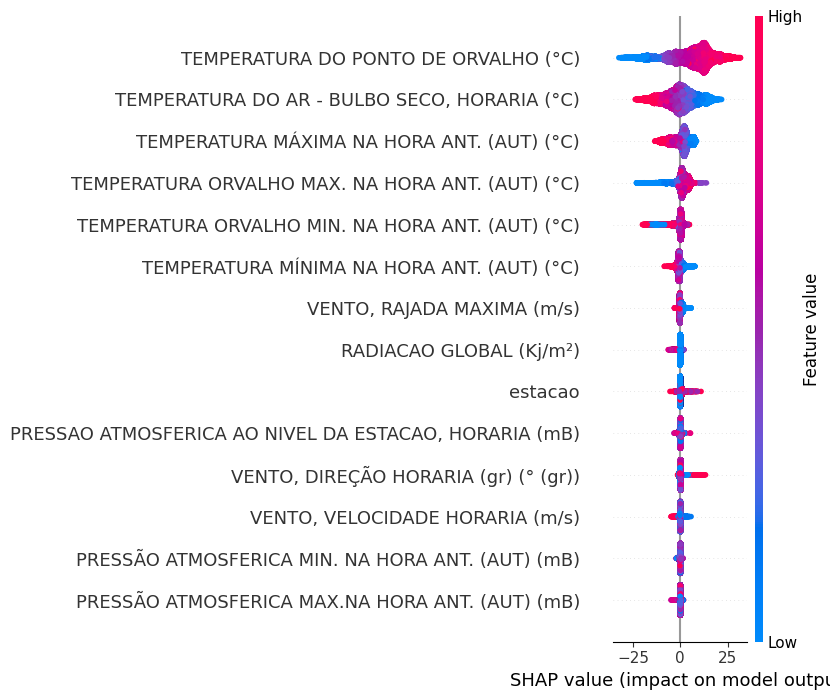

In [31]:
shap.summary_plot(shap_values.values, X_test)

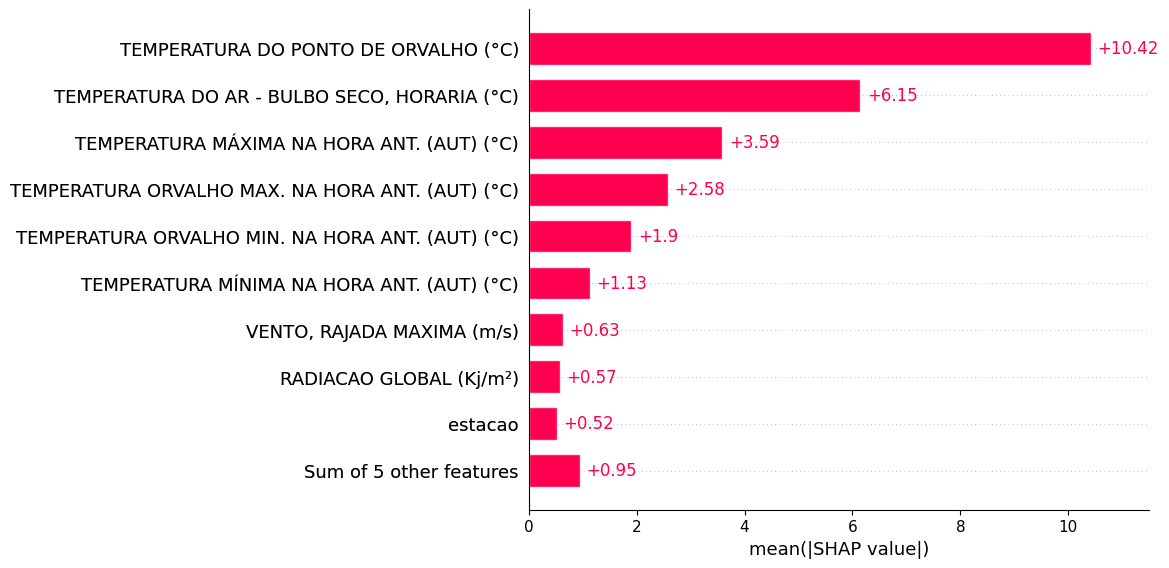

In [32]:
shap.plots.bar(shap_values)